# Tully-Fisher Relation of galaxies

For all galaxies in Iron (Y1) which have valid rotational velocities at $0.4R_{26}$, plot their TFR.  Also include the best-fit TFR (as calibrated using `TF_Y1_calibration_v18-KAD.ipynb` with redshift bins of width 0.005 but with no 0pt calibration.

**Change from v18:** The distance modulus is calculated with both $z_{\rm CMB}$ and $z_{\rm obs}$, not just $z_{\rm CMB}$.

In [1]:
from astropy.table import Table, join
from astropy.cosmology import Planck18, FlatLambdaCDM
from astropy.coordinates import Distance
from astropy.io import fits
from astropy.convolution import Gaussian2DKernel, convolve
import astropy.units as u
import astropy.constants as const

# from cosmoprimo.fiducial import DESI

from tqdm import tqdm

import numpy as np

from scipy.stats import binned_statistic
from scipy.optimize import curve_fit

import pickle

import os

import matplotlib.pyplot as plt

# Custom functions / classes
import sys
# sys.path.insert(1, '/global/u1/k/kadglass/DESI_SGA/TF/')
sys.path.insert(1, '/Users/kdouglass/Documents/Research/DESI/PV_survey/DESI_SGA/TF/')
# sys.path.insert(1, '/global/u1/s/sgmoore1/DESI_SGA/TF/')
from TF_photoCorrect import BASS_corr, MW_dust, k_corr, internal_dust
from z_CMB_convert import convert_z_frame
from help_functions import profile_histogram

In [2]:
h = 1
H0 = 100*h

c = const.c.to('km/s')

q0 = 0.2

In [3]:
cosmo = FlatLambdaCDM(H0=H0, Om0=0.3151)
# cosmo = DESI()

# Data

In [4]:
# SGA_TF = Table.read('/global/cfs/cdirs/desi/science/td/pv/tfgalaxies/Y1/SGA-2020_iron_Vrot_VI.fits')
# SGA_TF = Table.read('/global/cfs/cdirs/desi/science/td/pv/tfgalaxies/Y1/SGA-2020_iron_Vrot_dVsys_VI_photsys_v2.fits')
# SGA_TF = Table.read('SGA-2020_iron_Vrot_dVsys_VI_photsys_v2.fits')
# SGA_TF = Table.read('SGA-2020_iron_Vrot_VI_corr-20251030.fits') #<-- use for v15-17
SGA_TF = Table.read('SGA-2020_iron_Vrot_VI_corr_ba-20260706.fits') # <-- use for v18+
SGA_TF[:5]

SGA_ID,SGA_GALAXY,GALAXY,PGC,RA_LEDA,DEC_LEDA,MORPHTYPE,PA_LEDA,D25_LEDA,BA_LEDA,Z_LEDA,SB_D25_LEDA,MAG_LEDA,BYHAND,REF,GROUP_ID,GROUP_NAME,GROUP_MULT,GROUP_PRIMARY,GROUP_RA,GROUP_DEC,GROUP_DIAMETER,BRICKNAME,RA,DEC,D26,D26_REF,PA,BA,RA_MOMENT,DEC_MOMENT,SMA_MOMENT,G_SMA50,R_SMA50,Z_SMA50,SMA_SB22,SMA_SB22.5,SMA_SB23,SMA_SB23.5,SMA_SB24,SMA_SB24.5,SMA_SB25,SMA_SB25.5,SMA_SB26,G_MAG_SB22,R_MAG_SB22,Z_MAG_SB22,G_MAG_SB22.5,R_MAG_SB22.5,Z_MAG_SB22.5,G_MAG_SB23,R_MAG_SB23,Z_MAG_SB23,G_MAG_SB23.5,R_MAG_SB23.5,Z_MAG_SB23.5,G_MAG_SB24,R_MAG_SB24,Z_MAG_SB24,G_MAG_SB24.5,R_MAG_SB24.5,Z_MAG_SB24.5,G_MAG_SB25,R_MAG_SB25,Z_MAG_SB25,G_MAG_SB25.5,R_MAG_SB25.5,Z_MAG_SB25.5,G_MAG_SB26,R_MAG_SB26,Z_MAG_SB26,SMA_SB22_ERR,SMA_SB22.5_ERR,SMA_SB23_ERR,SMA_SB23.5_ERR,SMA_SB24_ERR,SMA_SB24.5_ERR,SMA_SB25_ERR,SMA_SB25.5_ERR,SMA_SB26_ERR,G_MAG_SB22_ERR,R_MAG_SB22_ERR,Z_MAG_SB22_ERR,G_MAG_SB22.5_ERR,R_MAG_SB22.5_ERR,Z_MAG_SB22.5_ERR,G_MAG_SB23_ERR,R_MAG_SB23_ERR,Z_MAG_SB23_ERR,G_MAG_SB23.5_ERR,R_MAG_SB23.5_ERR,Z_MAG_SB23.5_ERR,G_MAG_SB24_ERR,R_MAG_SB24_ERR,Z_MAG_SB24_ERR,G_MAG_SB24.5_ERR,R_MAG_SB24.5_ERR,Z_MAG_SB24.5_ERR,G_MAG_SB25_ERR,R_MAG_SB25_ERR,Z_MAG_SB25_ERR,G_MAG_SB25.5_ERR,R_MAG_SB25.5_ERR,Z_MAG_SB25.5_ERR,G_MAG_SB26_ERR,R_MAG_SB26_ERR,Z_MAG_SB26_ERR,G_COG_PARAMS_MTOT,G_COG_PARAMS_M0,G_COG_PARAMS_ALPHA1,G_COG_PARAMS_ALPHA2,G_COG_PARAMS_CHI2,R_COG_PARAMS_MTOT,R_COG_PARAMS_M0,R_COG_PARAMS_ALPHA1,R_COG_PARAMS_ALPHA2,R_COG_PARAMS_CHI2,Z_COG_PARAMS_MTOT,Z_COG_PARAMS_M0,Z_COG_PARAMS_ALPHA1,Z_COG_PARAMS_ALPHA2,Z_COG_PARAMS_CHI2,ELLIPSEBIT,Z_DESI,ZERR_DESI,V_0p4R26,V_0p4R26_ERR,PHOTSYS
int64,bytes16,bytes29,int64,float64,float64,bytes21,float32,float32,float32,float32,float32,float32,bool,bytes13,int64,bytes35,int16,bool,float64,float64,float32,bytes8,float64,float64,float32,bytes4,float32,float32,float64,float64,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,int32,float64,float64,float64,float64,bytes1
38,SGA-2020 38,SDSSJ140638.88+393138.1,3558705,211.66194,39.5272341,S?,81.63,0.35318315,0.37757218,0.08108376,24.72948,18.361,False,LEDA-20181114,12,SDSSJ140638.88+393138.1,1,True,211.66194,39.5272341,0.35318315,2115p395,211.66203166014844,39.52724032794356,0.41757938,SB26,82.21093,0.41431504,211.6619547015994,39.52729608884245,8.520181,5.252184,4.0750155,3.3951538,3.3006833,4.4037066,5.5453897,6.693271,7.8023033,8.999919,10.213078,11.41192,12.527382,19.246052,18.406073,17.931826,18.841032,18.092857,17.659027,18.566164,17.886087,17.47688,18.383362,17.749825,17.355968,18.261652,17.655558,17.284552,18.168955,17.588947,17.231817,18.101948,17.547142,17.20673,18.055267,17.516266,17.18719,18.023865,17.497095,17.178627,0.041267984,0.058114093,0.082968995,0.08808186,0.099526815,0.11876543,0.11355961,0.14645264,0.17035669,0.028041152,0.045385383,0.052895926,0.02822557,0.041093465,0.04698563,0.027371243,0.038240846,0.043213904,0.026219657,0.03618844,0.04070005,0.025270721,0.034526117,0.039107796,0.024264116,0.033164512,0.03780495,0.02343744,0.03226152,0.037176747,0.022813411,0.031564914,0.036686495,0.022342678,0.031088097,0.03649375,17.87426,0.7614885,0.3679447,2.3644495,0.004768816,17.421976,0.45777154,0.33258685,2.8184628,0.021122098,17.150808,0.27153513,0.24329957,3.8143618,0.0151183605,0,0.0809898865247745,2.5379500056923636e-05,122.3223893029039,11.74279844934265,N
55,SGA-2020 55,PGC120394

## Morphologies

Do our results improve if we only consider spiral and irregular galaxies?

In [5]:
ai_morphpath = '.'
# ai_morphpath = '/global/cfs/cdirs/desi/science/td/pv/SGA2020'
ai_morphcsv = os.path.join(ai_morphpath, 'TFY1_Classification.csv')

ai_morphtab = Table.read(ai_morphcsv)
ai_morphtab[:5]

SGA_ID,Spiral_Pred,Elliptical_Pred,Lenticular_Pred,Irregular_Pred
float64,str6,str10,str10,str9
2371.0,Other,Other,Other,Irregular
2406.0,Spiral,Other,Other,Other
4614.0,Spiral,Other,Other,Other
7707.0,Spiral,Other,Other,Other
8119.0,Spiral,Other,Other,Other


In [6]:
# Create an overall record of the SSL prediction
ai_morphtab['Predicted_Type'] = 'Undecided '

for i in range(len(ai_morphtab)):
    
    classes = ai_morphtab['Spiral_Pred', 'Elliptical_Pred', 'Lenticular_Pred', 'Irregular_Pred'][i]
    
    ai_morphtab['Predicted_Type'][i] = next(j for j in classes if j != 'Other')

### Combine ML morphtypes with SGA catalog

In [7]:
SGA_TF = join(SGA_TF, ai_morphtab['SGA_ID', 'Predicted_Type'], keys='SGA_ID', join_type='left')

# Rename Predicted_Type to MORPHTYPE_AI
SGA_TF['Predicted_Type'].name = 'MORPHTYPE_AI'

In [8]:
SGA_TF['SGA_ID', 'MORPHTYPE_AI'][:5]

SGA_ID,MORPHTYPE_AI
float64,str10
38.0,Spiral
55.0,Irregular
117.0,Spiral
223.0,Irregular
581.0,--


## John's VI results

https://astro.dur.ac.uk/~jrl/DESI_TF_Y1/index.html

We will also remove any galaxies that John identified as having significant asymmetry, double galaxies, or stellar contamination.

In [9]:
lucey_VIpath = 'VI_JohnLucey/'

rejects = lucey_VIpath + 'REJECTS.txt'

reject_tab = Table.read(rejects, format='ascii.commented_header')
reject_tab['VI'] = 'reject'
reject_tab

SGA_ID,DESI_NAME,RA,Dec,z_desi,V_0p4R26,V_0p4R26_err,V_PEC,V_ERR_PEC,VI
int64,str22,float64,float64,float64,int64,int64,int64,int64,str6
18171,DESIXJ21105773+0109527,317.74056,1.164637,0.0903,219,1,-555,542,reject
18900,DESIXJ13403122+0437086,205.130097,4.619043,0.0224,52,2,2647,351,reject
20828,DESIXJ20452158-0505449,311.339907,-5.095804,0.0522,97,1,9894,335,reject
24403,DESIXJ13023920-0257343,195.663329,-2.959515,0.0675,222,1,-2594,411,reject
34318,DESIXJ15173290+0109051,229.38709,1.151405,0.1257,235,38,7564,7706,reject
43314,DESIXJ19180598+6436397,289.524898,64.611027,0.0255,104,2,1327,299,reject
61768,DESIXJ23195165+0025234,349.965218,0.423153,0.0341,123,0,-305,278,reject
63092,DESIXJ14161558-0127527,214.064897,-1.46464,0.0363,149,0,-5767,286,reject
65921,DESIXJ21443087-0617367,326.12863,-6.293535,0.09,89,21,26924,8751,reject


### Combine John's results with Y1 TF sample

In [10]:
SGA_TF = join(SGA_TF, reject_tab['SGA_ID', 'VI'], keys='SGA_ID', join_type='left')

# Rename VI column to JOHN_VI
SGA_TF['VI'].name = 'JOHN_VI'

## Convert to CMB frame

In [11]:
SGA_TF['Z_DESI_CMB'] = convert_z_frame(SGA_TF['Z_DESI'], SGA_TF['RA'], SGA_TF['DEC'])

In [12]:
mu_cmb_old = cosmo.distmod(SGA_TF['Z_DESI_CMB'])
SGA_TF['MU_ZCMB'] = 5*np.log10(cosmo.comoving_distance(SGA_TF['Z_DESI_CMB']).value) + 5*np.log10(1 + SGA_TF['Z_DESI']) + 25

/var/folders/mg/fxh1s24d0n3_r0c39d3gs0g00000gq/T/ipykernel_77366/2010013303.py:2: RuntimeWarning: invalid value encountered in log10
  SGA_TF['MU_ZCMB'] = 5*np.log10(cosmo.comoving_distance(SGA_TF['Z_DESI_CMB']).value) + 5*np.log10(1 + SGA_TF['Z_DESI']) + 25


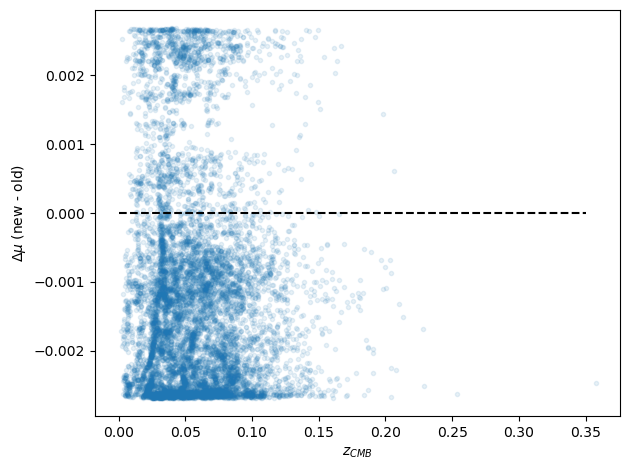

In [13]:
plt.figure(tight_layout=True)

# plt.plot(mu_cmb_old, SGA_TF['MU_ZCMB'], '.', alpha=0.1)
# plt.plot([28, 42], [28, 42], 'k:')
# plt.ylabel('new')
# plt.xlabel('old');

plt.plot(SGA_TF['Z_DESI_CMB'], SGA_TF['MU_ZCMB'] - mu_cmb_old.value, '.', alpha=0.1)
plt.hlines(0, xmin=0, xmax=0.35, colors='k', linestyles='dashed')
plt.ylabel('$\Delta \mu$ (new - old)')
plt.xlabel('$z_{CMB}$');

## Photometric corrections

### Survey offsets

In [14]:
sys_corr, sys_corr_err = BASS_corr(SGA_TF['PHOTSYS'])

### MW Dust corrections

In [15]:
# Import E(B-V) dust map
# ebv_directory = '/global/cfs/cdirs/desicollab/users/rongpu/dust/desi_ebv/public_data/maps/'
ebv_directory = '/Users/kdouglass/Documents/Research/data/DESI/'
ebv_filename = 'desi_dust_gr_512.fits'
ebv_map = Table.read(ebv_directory + ebv_filename)

In [16]:
MWdust_corr, MWdust_corr_err = MW_dust(SGA_TF['RA'], SGA_TF['DEC'], ebv_map)

/Users/kdouglass/Documents/Research/DESI/PV_survey/DESI_SGA/TF/TF_photoCorrect.py:90: UserWarning: Warning: converting a masked element to nan.
  EBV_err[i] = ebv_map['EBV_GR_ERR'][i_ebv]


In [17]:
# Flip NaN values to 0
MWdust_corr_err[np.isnan(MWdust_corr_err)] = 0

### $K$-corrections

In [18]:
# Apparently we have some galaxies with negative redshifts
zg0 = SGA_TF['Z_DESI'] >= 0

In [19]:
kcorr_zg0 = k_corr(SGA_TF['Z_DESI'][zg0], 
                   [SGA_TF['G_MAG_SB26'][zg0], SGA_TF['R_MAG_SB26'][zg0], SGA_TF['Z_MAG_SB26'][zg0]], 
                   [SGA_TF['G_MAG_SB26_ERR'][zg0], SGA_TF['R_MAG_SB26_ERR'][zg0], SGA_TF['Z_MAG_SB26_ERR'][zg0]], 
                   z_corr=0.1) # to match FastSpecFit / FP

In [20]:
kcorr = np.zeros([len(SGA_TF), 3])
kcorr[zg0] = kcorr_zg0

### Internal dust extinction correction

This is based off of a linear fit to ($b/a$, $m_r$), removing any correlation between $b/a$ and $m_r$.

In [21]:
temp_infile = open('iron_internalDust_z0p1_mcmc-20260708.pickle', 'rb')
dust_mcmc_samples_r,_, dust_mcmc_samples_g,_, dust_mcmc_samples_z,_ = pickle.load(temp_infile)
temp_infile.close()

In [22]:
internalDust_coeffs_r = np.median(dust_mcmc_samples_r, axis=1)
internalDust_coeffs_g = np.median(dust_mcmc_samples_g, axis=1)
internalDust_coeffs_z = np.median(dust_mcmc_samples_z, axis=1)

internalDust_coeffs_err_r = np.zeros(len(internalDust_coeffs_r))
internalDust_coeffs_err_g = np.zeros(len(internalDust_coeffs_g))
internalDust_coeffs_err_z = np.zeros(len(internalDust_coeffs_z))

internalDust_coeffs_err_r[0] = np.std(dust_mcmc_samples_r[0][(-1.5 < dust_mcmc_samples_r[0]) & (dust_mcmc_samples_r[0] < 0)])
internalDust_coeffs_err_r[1] = np.std(dust_mcmc_samples_r[1][(0 < dust_mcmc_samples_r[1]) & (dust_mcmc_samples_r[1] < 1)])

internalDust_coeffs_err_g[0] = np.std(dust_mcmc_samples_g[0][(-1.5 < dust_mcmc_samples_g[0]) & (dust_mcmc_samples_g[0] < 0)])
internalDust_coeffs_err_g[1] = np.std(dust_mcmc_samples_g[1][(0 < dust_mcmc_samples_g[1]) & (dust_mcmc_samples_g[1] < 1)])

internalDust_coeffs_err_z[0] = np.std(dust_mcmc_samples_z[0][(-1.5 < dust_mcmc_samples_z[0]) & (dust_mcmc_samples_z[0] < 0)])
internalDust_coeffs_err_z[1] = np.std(dust_mcmc_samples_z[1][(0 < dust_mcmc_samples_z[1]) & (dust_mcmc_samples_z[1] < 1)])

In [23]:
internalDust_corr_r, internalDust_corr_err_r = internal_dust(SGA_TF['BA'], 
                                                             internalDust_coeffs_r, 
                                                             internalDust_coeffs_err_r)

internalDust_corr_g, internalDust_corr_err_g = internal_dust(SGA_TF['BA'], 
                                                             internalDust_coeffs_g, 
                                                             internalDust_coeffs_err_g)

internalDust_corr_z, internalDust_corr_err_z = internal_dust(SGA_TF['BA'], 
                                                             internalDust_coeffs_z, 
                                                             internalDust_coeffs_err_z)

### Apply corrections

In [24]:
SGA_TF['G_MAG_SB26_CORR'] = SGA_TF['G_MAG_SB26'] - MWdust_corr[0] + sys_corr - kcorr[:,0] - internalDust_corr_g
SGA_TF['R_MAG_SB26_CORR'] = SGA_TF['R_MAG_SB26'] - MWdust_corr[1] + sys_corr - kcorr[:,1] - internalDust_corr_r
SGA_TF['Z_MAG_SB26_CORR'] = SGA_TF['Z_MAG_SB26'] - MWdust_corr[2] + sys_corr - kcorr[:,2] - internalDust_corr_z

In [25]:
SGA_TF['G_MAG_SB26_ERR_CORR'] = np.sqrt(SGA_TF['G_MAG_SB26_ERR']**2 + MWdust_corr_err[0]**2 + sys_corr_err**2 + internalDust_corr_err_g**2)
SGA_TF['R_MAG_SB26_ERR_CORR'] = np.sqrt(SGA_TF['R_MAG_SB26_ERR']**2 + MWdust_corr_err[1]**2 + sys_corr_err**2 + internalDust_corr_err_r**2)
SGA_TF['Z_MAG_SB26_ERR_CORR'] = np.sqrt(SGA_TF['Z_MAG_SB26_ERR']**2 + MWdust_corr_err[2]**2 + sys_corr_err**2 + internalDust_corr_err_z**2)

## Identify calibration sample

Requirements:
* $\Delta V/V_\mathrm{min} \leq 5$
* Passed visual inspection (both ours and John Lucey's)
* $i > 45^\circ$
* Spiral-type morphology
* Not a dwarf galaxy
* $70~\mathrm{km/s} < V_\mathrm{rot} < 300~\mathrm{km/s}$ at $0.4R_{26}$
* $\log(V_\mathrm{rot}) <$ minimum of log(300 km/s) or $0.3(\mu(z_{CMB}) - 34 - 5\log h) + 2$

The first 1.5 items have already been applied (our VI results have already been applied, but not John's).

In [26]:
#- Inclination cut
cosi2 = (SGA_TF['BA']**2 - q0**2) / (1 - q0**2)
i_min = 45. * u.degree
cosi2_max = np.cos(i_min)**2
is_good_incl = cosi2 < cosi2_max

#- Morphology cut: only ML
is_good_morph_ML = np.zeros_like(is_good_incl, dtype=bool)
for i in range(len(SGA_TF)):
    if SGA_TF['MORPHTYPE_AI'][i] == 'Spiral':
        is_good_morph_ML[i] = True

#- John's VI
is_good_John = SGA_TF['JOHN_VI'].mask

# Alex's velocity cut
Vmin = 70 # km/s
Vmax = 300 # km/s
is_good_vel = (SGA_TF['V_0p4R26'] > Vmin) & (SGA_TF['V_0p4R26'] < Vmax)

#- Alex's sliding velocity maximum
logVM_slope = 0.3
logVM_zero = 34 + 5*np.log10(h)
logVM_eff = np.minimum(Vmax, 10**(logVM_slope*(SGA_TF['MU_ZCMB'] - logVM_zero) + 2))
is_good_vel2 = SGA_TF['V_0p4R26'] < logVM_eff

#- Alex's dwarf galaxy definition
Rlim = 17.75
Mlim = -17 + 5*np.log10(h)
Rlim_eff = np.minimum(Rlim, SGA_TF['MU_ZCMB'] + Mlim)
dwarf_boolean = SGA_TF['R_MAG_SB26'] > Rlim_eff

#- Combine selections:
is_cal = is_good_incl & is_good_morph_ML & is_good_John & ~dwarf_boolean & is_good_vel & is_good_vel2

In [27]:
SGA_TF['CAL'] = is_cal

# TFR

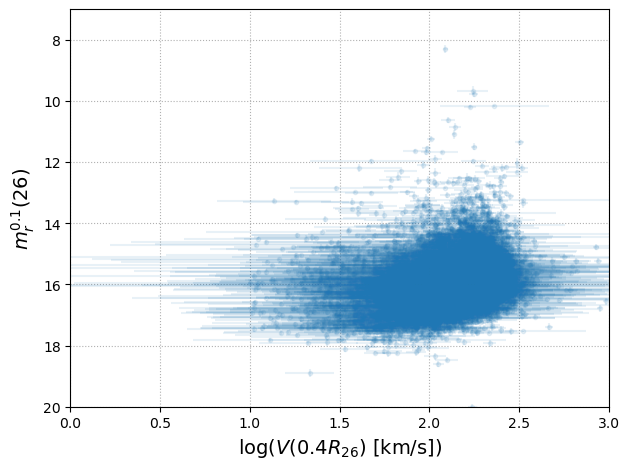

In [28]:
plt.figure(tight_layout=True)

plt.grid(ls=':')

plt.errorbar(np.log10(SGA_TF['V_0p4R26']), 
             SGA_TF['R_MAG_SB26_CORR'], 
             xerr=0.434*SGA_TF['V_0p4R26_ERR']/SGA_TF['V_0p4R26'],
             yerr=SGA_TF['R_MAG_SB26_ERR_CORR'], 
             fmt='.', 
             alpha=0.1)

plt.xlim([0, 3])
plt.ylim([20, 7])

plt.xlabel('log($V(0.4R_{26})$ [km/s])', fontsize=14)
plt.ylabel('$m_r^{0.1} (26)$', fontsize=14);

## Compute the absolute magnitudes based on the redshift

In [29]:
SGA_TF['R_ABSMAG_SB26'] = SGA_TF['R_MAG_SB26_CORR'] - SGA_TF['MU_ZCMB'].value

In [30]:
rng = np.random.default_rng()

N_samples = 1000

mu_err = np.empty(len(SGA_TF['MU_ZCMB']))*u.mag

for i in tqdm(range(len(mu_err))):

    zobs_desi_random = rng.normal(np.abs(SGA_TF['Z_DESI'][i]), 
                                  SGA_TF['ZERR_DESI'][i], 
                                  N_samples)
    
    zcmb_desi_random = convert_z_frame(zobs_desi_random, SGA_TF['RA'][i], SGA_TF['DEC'][i])
    
    # mu_random = cosmo.distmod(z_desi_random)
    mu_random = 5*np.log10(cosmo.comoving_distance(zcmb_desi_random).value) + 5*np.log10(1 + zobs_desi_random) + 25
    
    mu_err[i] = np.std(mu_random)*u.mag

SGA_TF['MU_ZCMB_ERR'] = mu_err

SGA_TF['R_ABSMAG_SB26_ERR'] = np.sqrt(SGA_TF['R_MAG_SB26_ERR_CORR']**2 + SGA_TF['MU_ZCMB_ERR'].value**2)

 92%|█████████████████████████████████   | 9356/10200 [00:02<00:00, 3513.58it/s]/var/folders/mg/fxh1s24d0n3_r0c39d3gs0g00000gq/T/ipykernel_77366/2500725020.py:16: RuntimeWarning: invalid value encountered in log10
  mu_random = 5*np.log10(cosmo.comoving_distance(zcmb_desi_random).value) + 5*np.log10(1 + zobs_desi_random) + 25
100%|███████████████████████████████████| 10200/10200 [00:02<00:00, 3461.24it/s]


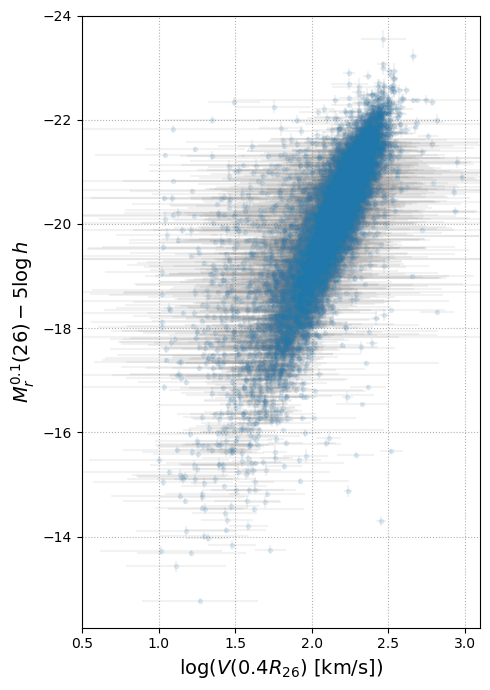

In [31]:
plt.figure(figsize=(5,7), tight_layout=True)

plt.grid(ls=':')

plt.errorbar(np.log10(SGA_TF['V_0p4R26']), 
             SGA_TF['R_ABSMAG_SB26'], 
             xerr=0.434*SGA_TF['V_0p4R26_ERR']/SGA_TF['V_0p4R26'],
             yerr=SGA_TF['R_ABSMAG_SB26_ERR'], 
             fmt='.', 
             alpha=0.1, 
             ecolor='gray')

plt.xlim([0.5, 3.1])
plt.ylim([-12.25, -24])

plt.xlabel('log($V(0.4R_{26})$ [km/s])', fontsize=14)
plt.ylabel('$M_r^{0.1} (26) - 5\log h$', fontsize=14);

## Plotted with our TFR

### Calibration without dwarfs

Here, $V_0$, the slope, and the y-intercepts are from `TF_Y1_calibration_v18-KAD.ipynb`:

\begin{equation}
  M_r = a \log\left(\frac{V(0.4R_{26})}{V_0}\right) + B(z_c)
\end{equation}

where $B(z_c) = b(z_c) - \mu(z_c)$, where $z_c$ is the center redshift of the relevant redshift bin.

In [32]:
# temp_infile = open('cov_ab_iron_jointTFR_varyV0-dwarfsAlex_z0p1_zbins0p005_weightsVmax-1_dVsys_KAD-20250813.pickle', <-- calibration used in DR1 cosmology
temp_infile = open('cov_ab_iron_v18_20260708.pickle', 
                   'rb')
cov_ab, tfr_samples, logV0, zmin, zmax, dz, zbins = pickle.load(temp_infile)
temp_infile.close()

In [33]:
len(zbins)

15

In [34]:
zbins

array([0.03 , 0.035, 0.04 , 0.045, 0.05 , 0.055, 0.06 , 0.065, 0.07 ,
       0.075, 0.08 , 0.085, 0.09 , 0.095, 0.1  ])

In [35]:
# Center redshift values of each bin
zc = 0.5*dz + zbins[:-1]

# Distance modulus for each redshift bin center
mu_zc = cosmo.distmod(zc)

In [36]:
slopes = tfr_samples[0]
slope = np.median(tfr_samples[0])
slope_err = np.sqrt(cov_ab[0,0])

# Each redshift bin has its own 0pt
# To put it in absolute-magnitude space, we'll convert it to an absolute magnitude using the middle of the redshift bin
ZPs = tfr_samples[1:-1] - mu_zc[:,None].value
ZP = np.median(tfr_samples[1:-1], axis=1) - mu_zc.value
ZP_err = np.sqrt(np.diagonal(cov_ab[1:-1,1:-1])) # Should include z-bin width to this uncertainty

sig = np.median(tfr_samples[-1])

logv = np.linspace(-1*np.ones(len(zbins)-1), 3.5*np.ones(len(zbins)-1), 100)
absmag = slope*(logv - logV0) + ZP

In [37]:
ZP_rms = np.sqrt(np.sum(ZP**2)/len(ZP))

mean_ZP = np.average(ZP, weights=ZP_err**-2)

rng = np.random.default_rng()
N_samples = 10000
ZP_random = np.zeros((len(ZP), N_samples))

for i in range(len(ZP)):
    ZP_random[i] = rng.normal(loc=ZP[i], scale=ZP_err[i], size=N_samples)

avg_ZP_random = np.average(ZP_random, 
                           weights=np.ones(N_samples)*ZP_err[:,None]**-2, 
                           axis=0)
mean_ZP_err = np.std(avg_ZP_random)

print(f'RMS of B_i: {ZP_rms:.2f}')
print(f'weighted mean of B_i: {mean_ZP:.2f} +/- {mean_ZP_err:.3f}')

RMS of B_i: 20.32
weighted mean of B_i: -20.31 +/- 0.008


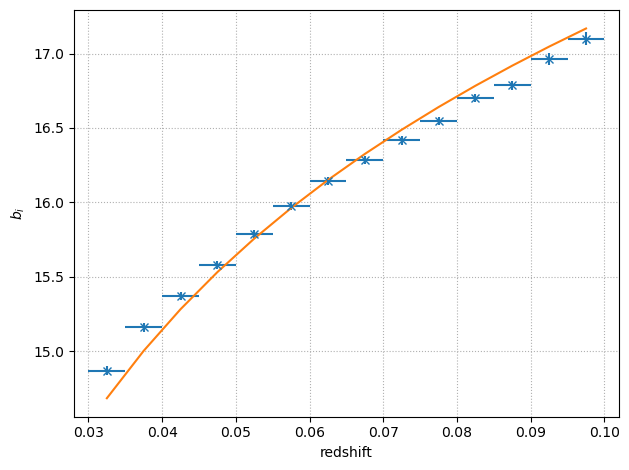

In [38]:
plt.figure(tight_layout=True)

plt.grid(ls=':')

plt.errorbar(zc, np.median(tfr_samples[1:-1], axis=1), 
             xerr=0.5*dz, 
             yerr=ZP_err, 
             fmt='x')

plt.plot(zc, mu_zc + mean_ZP*u.mag)

plt.xlim(0.028, 0.102)

plt.xlabel('redshift')
plt.ylabel('$b_i$');

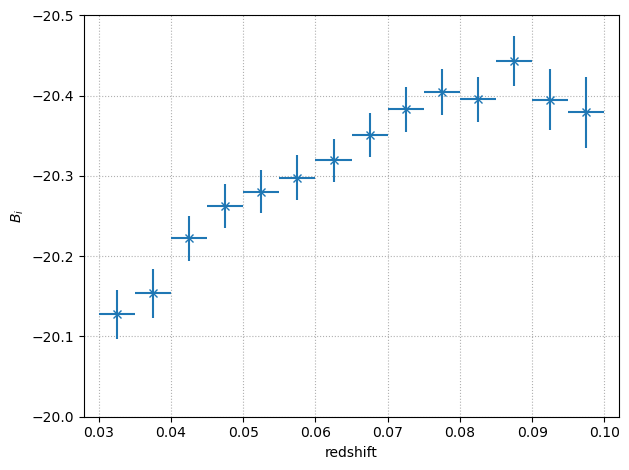

In [39]:
plt.figure(tight_layout=True)

plt.grid(ls=':')

plt.errorbar(zc, ZP, 
             xerr=0.5*dz, 
             yerr=ZP_err, 
             fmt='x')

plt.xlim(0.028, 0.102)
plt.ylim(-20, -20.5)

plt.xlabel('redshift')
plt.ylabel('$B_i$');

# plt.savefig('../../../figures/Y1_papers/TF_Y1_Bi-z_v13.png', dpi=150, facecolor='none');

In [40]:
# This cell needs to be updated for each redshift bin
'''
# Calculate the uncertainties in the calibrated TFR
slopes = tfr_samples[0]
ZPs = tfr_samples[1:-1]

N_samples = len(slopes)

lines = []

for i in range(N_samples):
    # Transform zero-points
    
    lines.append(slopes[i]*(logv - V0) + ZPs[i])
    
lines_array = np.asarray(lines)
line_err = np.nanpercentile(lines_array, [16 ,84], axis=0)
''';

In [41]:
spiral_boolean = SGA_TF['MORPHTYPE_AI'] == 'Spiral'
irregular_boolean = SGA_TF['MORPHTYPE_AI'] == 'Irregular'
# other_boolean = SGA_TF['MORPHTYPE_AI'] == 'Other'

VI_boolean = SGA_TF['JOHN_VI'].mask

morph_boolean = (spiral_boolean | irregular_boolean) & VI_boolean

In [42]:
# Alex's velocity cut
Vmin = 70 # km/s
Vmax = 300 # km/s
is_good_vel = (SGA_TF['V_0p4R26'] > Vmin) & (SGA_TF['V_0p4R26'] < Vmax)

#- Alex's sliding velocity maximum
logVM_slope = 0.3
logVM_zero = 34 + 5*np.log10(h)
is_good_vel2 = SGA_TF['V_0p4R26'] < np.minimum(Vmax, 10**(logVM_slope*(SGA_TF['MU_ZCMB'] - logVM_zero) + 2))

In [43]:
SGA_TF['DWARF'] = dwarf_boolean
SGA_TF['GOOD_MORPH'] = morph_boolean
SGA_TF['GOOD_VEL'] = is_good_vel & is_good_vel2

print(sum(dwarf_boolean), 'dwarfs')
print(len(SGA_TF) - sum(dwarf_boolean), 'non-dwarfs')
print('-----------')
print(sum(~dwarf_boolean & is_good_vel & is_good_vel2), "non-dwarfs that pass Alex's velocity cuts")
print('-----------')
print(np.sum(morph_boolean), 'spirals & irregulars that pass VI')
print(np.sum(morph_boolean & dwarf_boolean), 'dwarfs')
print(np.sum(morph_boolean & ~dwarf_boolean), 'non-dwarfs')

# print(sum(dwarf_boolean_corr), 'dwarfs')
# print(len(SGA_TF_corr) - sum(dwarf_boolean_corr), 'non-dwarfs')

570 dwarfs
9630 non-dwarfs
-----------
8051 non-dwarfs that pass Alex's velocity cuts
-----------
9212 spirals & irregulars that pass VI
492 dwarfs
8720 non-dwarfs


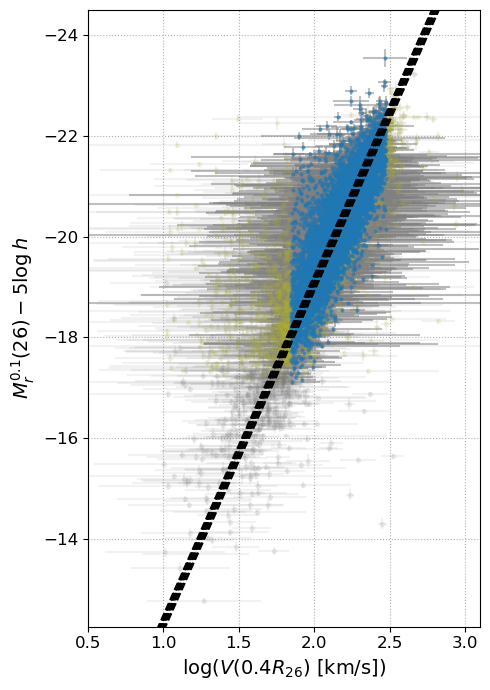

In [44]:
plt.figure(figsize=(5,7), tight_layout=True)

plt.grid(ls=':')

# plt.fill_between(logv, line_err[0], line_err[1], color='lightgray')

sample = dwarf_boolean# & morph_boolean
plt.errorbar(np.log10(SGA_TF['V_0p4R26'][sample]), 
             SGA_TF['R_ABSMAG_SB26'][sample], 
             xerr=0.434*SGA_TF['V_0p4R26_ERR'][sample]/SGA_TF['V_0p4R26'][sample],
             yerr=SGA_TF['R_ABSMAG_SB26_ERR'][sample], 
             fmt='.',
             color='gray',
             alpha=0.1, 
             ecolor='gray')

sample = ~SGA_TF['GOOD_VEL'] & ~dwarf_boolean
plt.errorbar(np.log10(SGA_TF['V_0p4R26'][sample]), 
             SGA_TF['R_ABSMAG_SB26'][sample], 
             xerr=0.434*SGA_TF['V_0p4R26_ERR'][sample]/SGA_TF['V_0p4R26'][sample],
             yerr=SGA_TF['R_ABSMAG_SB26_ERR'][sample], 
             fmt='.',
             color='tab:olive',
             # color='gray',
             alpha=0.1, 
             ecolor='gray')

sample = ~dwarf_boolean & is_good_vel & is_good_vel2
plt.errorbar(np.log10(SGA_TF['V_0p4R26'][sample]), 
             SGA_TF['R_ABSMAG_SB26'][sample], 
             xerr=0.434*SGA_TF['V_0p4R26_ERR'][sample]/SGA_TF['V_0p4R26'][sample],
             yerr=SGA_TF['R_ABSMAG_SB26_ERR'][sample], 
             fmt='.', 
             markersize=4, 
             alpha=0.5, 
             ecolor='gray')

plt.plot(logv, absmag, 'k--', zorder=3)

plt.xlim([0.5, 3.1])
plt.ylim([-12.25, -24.5])

plt.xlabel('log($V(0.4R_{26})$ [km/s])', fontsize=14)
plt.ylabel('$M_r^{0.1} (26) - 5\log h$', fontsize=14);

ax = plt.gca()
ax.tick_params(axis='both', which='major', labelsize=12);

# plt.savefig('../../../figures/Y1_papers/iron_jointTFR_dwarfAlex_dz0p005_weightsVmax-1_20250810.png', 
#             dpi=150, 
#             facecolor='none')

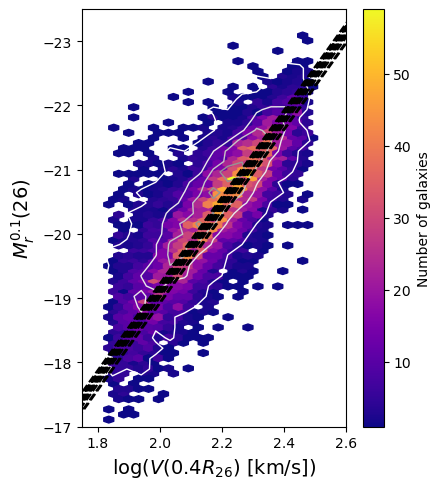

In [45]:
plt.figure(figsize=(4.5,5), tight_layout=True)

plt.hexbin(np.log10(SGA_TF['V_0p4R26'][~dwarf_boolean & SGA_TF['GOOD_VEL']]), 
           SGA_TF['R_ABSMAG_SB26'][~dwarf_boolean & SGA_TF['GOOD_VEL']], 
           cmap='plasma', 
           mincnt=1, 
           gridsize=(100,80), 
           extent=(-0.1, 3.1, -25, -12.25))
plt.colorbar(label='Number of galaxies')

# Plot calibration galaxies as contours
_N, _edges_x, _edges_y = np.histogram2d(np.log10(SGA_TF['V_0p4R26'][SGA_TF['CAL']]), 
                                        SGA_TF['R_ABSMAG_SB26'][SGA_TF['CAL']], 
                                        bins=(np.linspace(-0.1, 3.1, 70), np.linspace(-25, -12.25, 80)))
_mesh_x, _mesh_y = np.meshgrid(_edges_x[:-1], _edges_y[:-1], indexing='ij')
# _kernel = Gaussian2DKernel(x_stddev=1, y_stddev=1)
# _Nsmooth = convolve(_N, _kernel)
plt.contour(_mesh_x, _mesh_y, _N, levels=np.linspace(3,150,7), linewidths=1, cmap='Grays', zorder=2)

# plt.fill_between(logv, line_err[0], line_err[1], color='lightgray', alpha=0.2)
plt.plot(logv, absmag, 'k--', zorder=3)

plt.xlim([1.75, 2.6])
plt.ylim([-17, -23.5])

plt.xlabel('log($V(0.4R_{26})$ [km/s])', fontsize=14)
plt.ylabel('$M_r^{0.1} (26)$', fontsize=14);

#### Redshift distribution

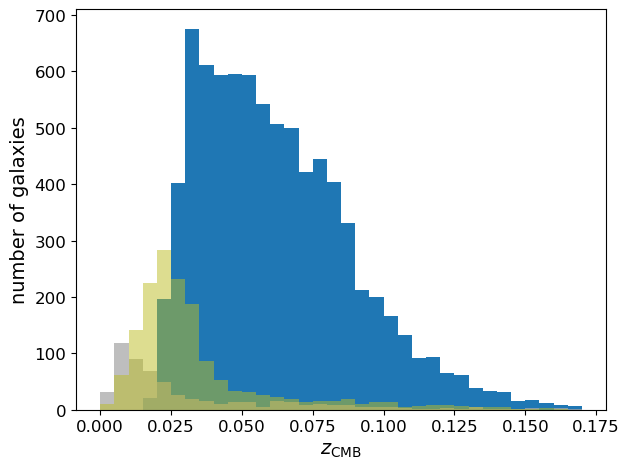

In [46]:
plt.figure(tight_layout=True)

plt.hist(SGA_TF['Z_DESI_CMB'][~dwarf_boolean & SGA_TF['GOOD_VEL']],
         bins=np.arange(0, 0.175, 0.005))

plt.hist(SGA_TF['Z_DESI_CMB'][dwarf_boolean],
         bins=np.arange(0, 0.175, 0.005), 
         color='darkgray',
         alpha=0.75)

plt.hist(SGA_TF['Z_DESI_CMB'][~dwarf_boolean & ~SGA_TF['GOOD_VEL']],
         bins=np.arange(0, 0.175, 0.005), 
         color='tab:olive',
         alpha=0.5)

plt.tick_params(axis='both', which='major', labelsize=12)

plt.xlabel(r'$z_{\text{CMB}}$', fontsize=14)
plt.ylabel('number of galaxies', fontsize=14);

# Distance moduli

In [47]:
# First, match each galaxy to its redshift bin
zbin_indices = np.digitize(SGA_TF['Z_DESI_CMB'], zbins, right=True)

# For those galaxies that fall outside the calibration range, assign them to the closest bin
zbin_indices[zbin_indices == 0] = 1
zbin_indices[zbin_indices == len(zbins)] = len(zbins) - 1

# Then, use that galaxy's redshift bin's zero-point to calculate the distance modulus
SGA_TF['R_ABSMAG_SB26_TF'] = np.nan
for i in range(len(SGA_TF)):
    SGA_TF['R_ABSMAG_SB26_TF'][i] = slope*(np.log10(SGA_TF['V_0p4R26'][i]) - logV0) + ZP[zbin_indices[i] - 1]

In [48]:
SGA_TF['R_ABSMAG_SB26_TF_ERR'] = np.nan
SGA_TF['R_ABSMAG_SB26_TF_ERR_STAT'] = np.nan

rng = np.random.default_rng()

for i in tqdm(range(len(SGA_TF))):
    
    v_random = rng.normal(SGA_TF['V_0p4R26'][i], 
                          SGA_TF['V_0p4R26_ERR'][i], 
                          # size=10000
                          size=len(slopes)
                         )
    v_random_good = v_random[v_random > 0]

    ############################################################################
    # Statistical uncertainty
    #---------------------------------------------------------------------------
    Ms_stat = slope*(np.log10(v_random_good) - logV0) + ZP[zbin_indices[i] - 1]

    SGA_TF['R_ABSMAG_SB26_TF_ERR_STAT'][i] = np.nanstd(Ms_stat)
    ############################################################################

    
    ############################################################################
    # Total uncertainty
    #---------------------------------------------------------------------------
    Ms = slopes[v_random > 0]*(np.log10(v_random_good) - logV0) + ZPs[zbin_indices[i] - 1,v_random > 0]
    
    SGA_TF['R_ABSMAG_SB26_TF_ERR'][i] = np.sqrt(np.nanstd(Ms)**2 + sig**2)
    ############################################################################
    

################################################################################
# Systematic uncertainty
#-------------------------------------------------------------------------------
SGA_TF['R_ABSMAG_SB26_TF_ERR_SYS'] = np.sqrt(SGA_TF['R_ABSMAG_SB26_TF_ERR']**2 - SGA_TF['R_ABSMAG_SB26_TF_ERR_STAT']**2)
################################################################################

100%|█████████████████████████████████████| 10200/10200 [05:16<00:00, 32.27it/s]


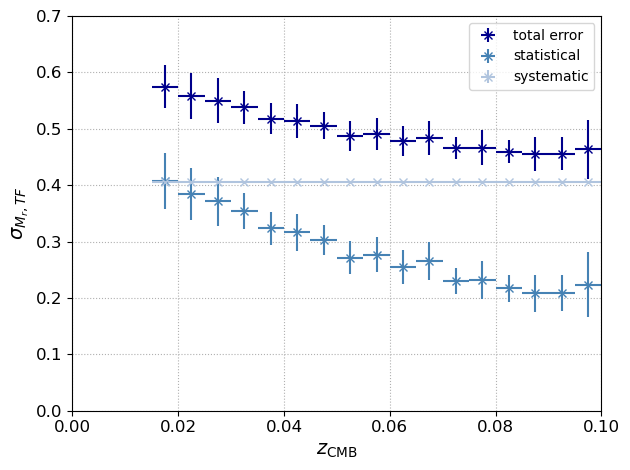

In [49]:
_zbins = np.arange(0, 0.105, 0.005)
_dz = 0.5*np.diff(_zbins)
_zc = 0.5*(_zbins[1:] + _zbins[:-1])

sample1 = ~dwarf_boolean & SGA_TF['GOOD_VEL'] & spiral_boolean
# sample2 = dwarf_boolean
# sample3 = ~dwarf_boolean & ~SGA_TF['GOOD_VEL']

plt.figure(tight_layout=True)

# plt.plot(tf_data['Z_DESI_CMB'][sample1], tf_data['R_ABSMAG_SB26_TF_ERR'][sample1], '.', alpha=0.1)

# Total uncertainty
N, y_avg, y_std = profile_histogram(SGA_TF['Z_DESI_CMB'][sample1], 
                                    SGA_TF['R_ABSMAG_SB26_TF_ERR'][sample1], 
                                    _zbins, 
                                    stat='median')
plt.errorbar(_zc, y_avg, xerr=_dz, yerr=y_std, fmt='x', color='darkblue', label='total error')

# Statistical uncertainty (just from velocity uncertainty)
N, y_avg, y_std = profile_histogram(SGA_TF['Z_DESI_CMB'][sample1], 
                                    SGA_TF['R_ABSMAG_SB26_TF_ERR_STAT'][sample1], 
                                    _zbins, 
                                    stat='median')
plt.errorbar(_zc, y_avg, xerr=_dz, yerr=y_std, fmt='x', color='steelblue', label='statistical')

# Systematic uncertainty (from TF calibration)
N, y_avg, y_std = profile_histogram(SGA_TF['Z_DESI_CMB'][sample1], 
                                    SGA_TF['R_ABSMAG_SB26_TF_ERR_SYS'][sample1], 
                                    _zbins, 
                                    stat='median')
plt.errorbar(_zc, y_avg, xerr=_dz, yerr=y_std, fmt='x', color='lightsteelblue', label='systematic')

plt.grid(ls=':')

plt.legend()

plt.xlim(0, 0.1)
plt.ylim(0, 0.7)

plt.tick_params(axis='both', which='major', labelsize=12)

plt.xlabel(r'$z_{\text{CMB}}$', fontsize=14)
plt.ylabel(r'$\sigma_{M_r, TF}$', fontsize=14);

## Compute distance modulus based on our TFR

In [50]:
SGA_TF['MU_TF'] = SGA_TF['R_MAG_SB26_CORR'] - SGA_TF['R_ABSMAG_SB26_TF']

SGA_TF['MU_TF_ERR'] = np.sqrt(SGA_TF['R_MAG_SB26_ERR_CORR']**2 + SGA_TF['R_ABSMAG_SB26_TF_ERR']**2)

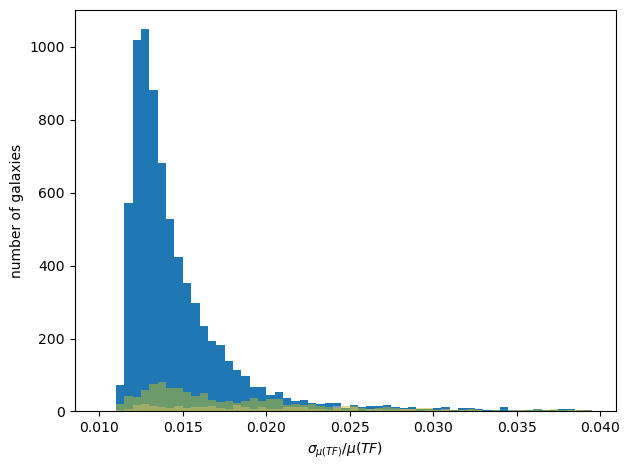

In [51]:
plt.figure(tight_layout=True)

sample1 = ~dwarf_boolean & SGA_TF['GOOD_VEL']
sample2 = dwarf_boolean
sample3 = ~dwarf_boolean & ~SGA_TF['GOOD_VEL']

plt.hist(SGA_TF['MU_TF_ERR'][sample1]/SGA_TF['MU_TF'][sample1], bins=np.arange(0.01, 0.04, 0.0005))
plt.hist(SGA_TF['MU_TF_ERR'][sample2]/SGA_TF['MU_TF'][sample2], bins=np.arange(0.01, 0.04, 0.0005), color='darkgray', alpha=0.75)
plt.hist(SGA_TF['MU_TF_ERR'][sample3]/SGA_TF['MU_TF'][sample3], bins=np.arange(0.01, 0.04, 0.0005), color='tab:olive', alpha=0.5)

plt.xlabel('$\sigma_{\mu(TF)} / \mu(TF)$')
plt.ylabel('number of galaxies');

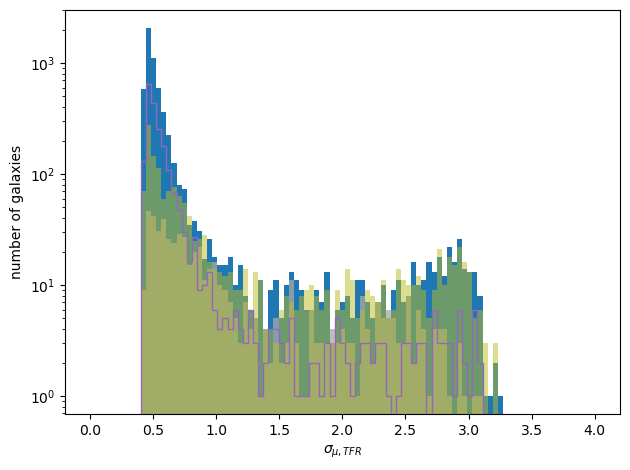

In [65]:
plt.figure(tight_layout=True)

sample1 = ~dwarf_boolean & SGA_TF['GOOD_VEL'] & spiral_boolean
sample2 = dwarf_boolean
sample3 = ~dwarf_boolean & ~SGA_TF['GOOD_VEL']
sample4 = ~dwarf_boolean & SGA_TF['GOOD_VEL'] & ~spiral_boolean

# _mu_bins = np.arange(0.09, 0.2, 0.001)
_mu_bins = np.linspace(0, 4, 100)

plt.hist(SGA_TF['MU_TF_ERR'][sample1], bins=_mu_bins)
plt.hist(SGA_TF['MU_TF_ERR'][sample2], bins=_mu_bins, color='darkgray', alpha=0.75)
plt.hist(SGA_TF['MU_TF_ERR'][sample3], bins=_mu_bins, color='tab:olive', alpha=0.5)
plt.hist(SGA_TF['MU_TF_ERR'][sample4], bins=_mu_bins, color='tab:purple', histtype='step')

plt.yscale('log')

plt.xlabel('$\sigma_{\mu, TFR}$')
plt.ylabel('number of galaxies');

## $\eta$ v. redshift

In [52]:
SGA_TF['LOGDIST'] = 0.2*(SGA_TF['MU_ZCMB'] - SGA_TF['MU_TF'])
SGA_TF['LOGDIST_ERR'] = 0.2*np.sqrt(SGA_TF['MU_ZCMB_ERR']**2 + SGA_TF['MU_TF_ERR']**2)

In [53]:
# Fit a Gaussian to the pull distribution, and plot it on top of the histogram

def gaussian(x, A, x0, sigma):
    '''
    normal dist

    PARAMETERS
    ==========

    x : array
        data
    A : float
        coefficient
    x0 : float
        mean
    sigma : float
        width
    
    RETURNS
    =======
    gaussian w parameters
    '''

    return A * np.exp(-(x-x0)**2/(2*sigma**2))

[3.68123501e+02 7.06420845e-02 8.45863890e-01]


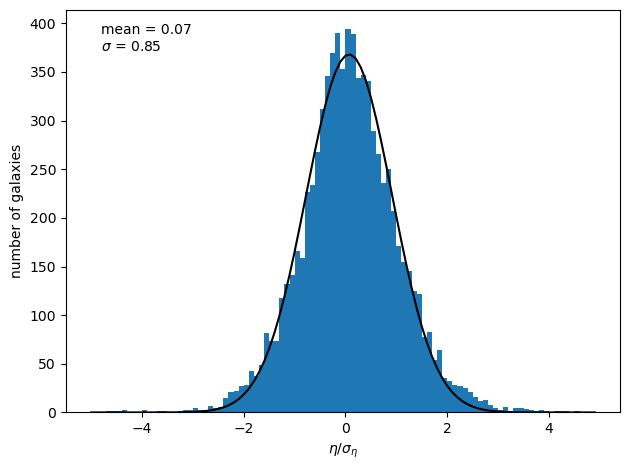

In [54]:
sample1 = ~dwarf_boolean & SGA_TF['GOOD_VEL'] #& spiral_boolean
sample2 = dwarf_boolean
sample3 = ~dwarf_boolean & ~SGA_TF['GOOD_VEL']
sample4 = ~dwarf_boolean & SGA_TF['GOOD_VEL'] & ~spiral_boolean

pull_bins = np.arange(-5, 5, 0.1)
bin_ctrs = 0.5*(pull_bins[1:] + pull_bins[:-1])

counts,_ = np.histogram(SGA_TF['LOGDIST'][sample1]/SGA_TF['LOGDIST_ERR'][sample1], 
                        bins=pull_bins)
mean_guess = np.mean(SGA_TF['LOGDIST'][sample1]/SGA_TF['LOGDIST_ERR'][sample1])
std_guess = np.std(SGA_TF['LOGDIST'][sample1]/SGA_TF['LOGDIST_ERR'][sample1])
p0 = [200, mean_guess, std_guess]

popt_eta, pcov = curve_fit(gaussian, bin_ctrs, counts, p0=p0)
print(popt_eta)


plt.figure(tight_layout=True)

plt.hist(SGA_TF['LOGDIST'][sample1]/SGA_TF['LOGDIST_ERR'][sample1], bins=pull_bins)
# plt.hist(SGA_TF['LOGDIST'][sample2]/np.abs(SGA_TF['LOGDIST_ERR'][sample2]), bins=pull_bins, color='darkgray', alpha=0.75)
# plt.hist(SGA_TF['LOGDIST'][sample3]/np.abs(SGA_TF['LOGDIST_ERR'][sample3]), bins=pull_bins, color='tab:olive', alpha=0.5)
# plt.hist(SGA_TF['LOGDIST'][sample4]/np.abs(SGA_TF['LOGDIST_ERR'][sample4]), bins=pull_bins, color='tab:orange', histtype='step')

plt.plot(pull_bins, gaussian(pull_bins, *popt_eta), 'k')

plt.annotate(f'mean = {popt_eta[1]:.2f}\n$\sigma$ = {popt_eta[2]:.2f}', (-4.8, 400), va='top')

plt.xlabel('$\eta / \sigma_{\eta}$')
plt.ylabel('number of galaxies');

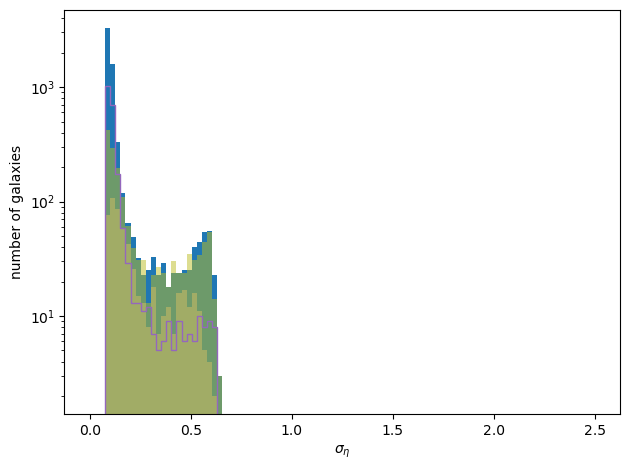

In [57]:
plt.figure(tight_layout=True)

sample1 = ~dwarf_boolean & SGA_TF['GOOD_VEL'] & spiral_boolean
sample2 = dwarf_boolean
sample3 = ~dwarf_boolean & ~SGA_TF['GOOD_VEL']
sample4 = ~dwarf_boolean & SGA_TF['GOOD_VEL'] & ~spiral_boolean

# _eta_bins = np.arange(0.09, 0.2, 0.001)
_eta_bins = np.linspace(0, 2.5, 100)

plt.hist(SGA_TF['LOGDIST_ERR'][sample1], bins=_eta_bins)
plt.hist(SGA_TF['LOGDIST_ERR'][sample2], bins=_eta_bins, color='darkgray', alpha=0.75)
plt.hist(SGA_TF['LOGDIST_ERR'][sample3], bins=_eta_bins, color='tab:olive', alpha=0.5)
plt.hist(SGA_TF['LOGDIST_ERR'][sample4], bins=_eta_bins, color='tab:purple', histtype='step')

plt.yscale('log')

plt.xlabel('$\sigma_{\eta}$')
plt.ylabel('number of galaxies');

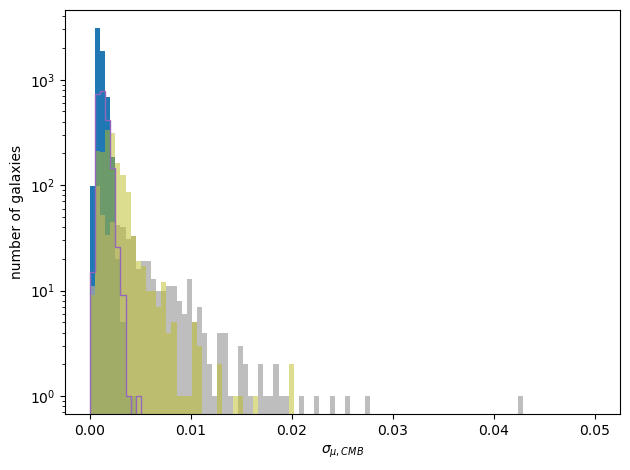

In [61]:
plt.figure(tight_layout=True)

sample1 = ~dwarf_boolean & SGA_TF['GOOD_VEL'] & spiral_boolean
sample2 = dwarf_boolean
sample3 = ~dwarf_boolean & ~SGA_TF['GOOD_VEL']
sample4 = ~dwarf_boolean & SGA_TF['GOOD_VEL'] & ~spiral_boolean

# _mu_bins = np.arange(0.09, 0.2, 0.001)
_mu_bins = np.linspace(0, 0.05, 100)

plt.hist(SGA_TF['MU_ZCMB_ERR'][sample1], bins=_mu_bins)
plt.hist(SGA_TF['MU_ZCMB_ERR'][sample2], bins=_mu_bins, color='darkgray', alpha=0.75)
plt.hist(SGA_TF['MU_ZCMB_ERR'][sample3], bins=_mu_bins, color='tab:olive', alpha=0.5)
plt.hist(SGA_TF['MU_ZCMB_ERR'][sample4], bins=_mu_bins, color='tab:purple', histtype='step')

plt.yscale('log')

plt.xlabel('$\sigma_{\mu, CMB}$')
plt.ylabel('number of galaxies');

/Users/kdouglass/Documents/Research/DESI/PV_survey/DESI_SGA/TF/help_functions.py:62: RuntimeWarning: invalid value encountered in divide
  h = H/W
/Users/kdouglass/Documents/Research/DESI/PV_survey/DESI_SGA/TF/help_functions.py:63: RuntimeWarning: divide by zero encountered in divide
  e = 1/np.sqrt(W)


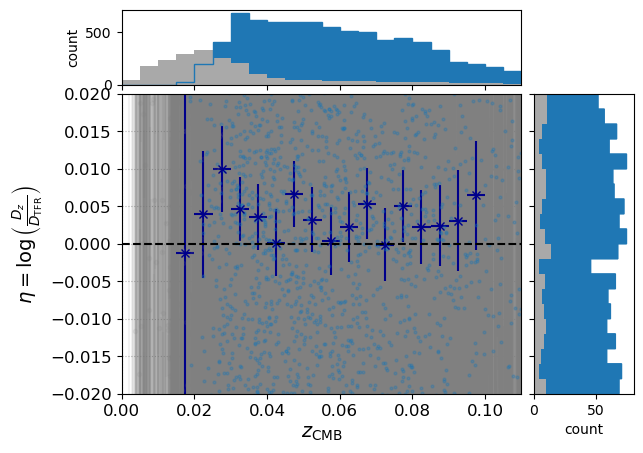

In [59]:
_zbins = np.arange(0, 0.105, 0.005)
_dz = 0.5*np.diff(_zbins)
_zc = 0.5*(_zbins[1:] + _zbins[:-1])

sample1 = ~dwarf_boolean & SGA_TF['GOOD_VEL']# & spiral_boolean
sample2 = dwarf_boolean
sample3 = ~dwarf_boolean & ~SGA_TF['GOOD_VEL']
sample4 = ~dwarf_boolean & SGA_TF['GOOD_VEL'] & ~spiral_boolean

fig = plt.figure()

gs = fig.add_gridspec(2, 2, width_ratios=(4,1), height_ratios=(1,4), left=0.1, right=0.9, bottom=0.1, top=0.9, wspace=0.05, hspace=0.05)

ax = fig.add_subplot(gs[1,0])
ax.errorbar(SGA_TF['Z_DESI_CMB'][~sample1], 
            SGA_TF['LOGDIST'][~sample1], 
            xerr=SGA_TF['ZERR_DESI'][~sample1], 
            yerr=SGA_TF['LOGDIST_ERR'][~sample1],
            fmt='.', 
            color='gray',
            alpha=0.1, 
            ecolor='gray')
'''
ax.errorbar(SGA_TF['Z_DESI_CMB'][sample3], 
             SGA_TF['LOGDIST'][sample3], 
             xerr=SGA_TF['ZERR_DESI'][sample3], 
             yerr=SGA_TF['LOGDIST_ERR'][sample3],
             fmt='.', 
             color='tab:olive',
             alpha=0.1, 
             ecolor='gray')
'''
ax.errorbar(SGA_TF['Z_DESI_CMB'][sample1], 
            SGA_TF['LOGDIST'][sample1], 
            xerr=SGA_TF['ZERR_DESI'][sample1], 
            yerr=SGA_TF['LOGDIST_ERR'][sample1],
            fmt='.', 
            markersize=4, 
            alpha=0.3, 
            ecolor='gray')

# Plot the weighted mean
N, y_avg, y_std = profile_histogram(SGA_TF['Z_DESI_CMB'][sample1], 
                                    SGA_TF['LOGDIST'][sample1], 
                                    _zbins, 
                                    weights=SGA_TF['LOGDIST_ERR'][sample1]**-2, 
                                    weighted=True)
ax.errorbar(_zc, y_avg, xerr=_dz, yerr=y_std, fmt='x', 
            color='darkblue', 
            # color='m',
            label='weighted mean')
'''
# Plot the median
N, y_avg, y_std = profile_histogram(SGA_TF['Z_DESI_CMB'][sample1], 
                                    SGA_TF['LOGDIST'][sample1], 
                                    _zbins, 
                                    stat='median')
ax.errorbar(zc, y_avg, xerr=dz, yerr=y_std, fmt='x', color='lightsteelblue', label='median')

ax.legend()
'''

# Line at eta = 0
ax.hlines(0, 0, 0.2, linestyles='dashed', colors='k', zorder=5)

ax.grid(ls=':')

plt.tick_params(axis='both', which='major', labelsize=12)

ax.set_xlabel(r'$z_{\text{CMB}}$', fontsize=14)
ax.set_ylabel(r'$\eta = \log \left( \frac{D_z}{D_{\text{TFR}}} \right)$', fontsize=14)

# ax.set_ylim((-1, 1))
# ax.set_xlim((0, 0.2))
# ax.set_ylim((-0.1, 0.1))
ax.set_ylim((-0.02, 0.02))
ax.set_xlim((0, 0.11))

ax.grid(ls=':')


ax_histx = fig.add_subplot(gs[0,0], sharex=ax)
ax_histx.hist(SGA_TF['Z_DESI_CMB'][sample1], 
              bins=np.arange(0, 0.175, 0.005))
ax_histx.hist(SGA_TF['Z_DESI_CMB'][~sample1], 
              bins=np.arange(0, 0.175, 0.005), 
              color='darkgray')
'''
ax_histx.hist(SGA_TF['Z_DESI_CMB'][sample3], 
              bins=np.arange(0, 0.175, 0.005), 
              color='tab:olive')
ax_histx.hist(SGA_TF['Z_DESI_CMB'][sample2], 
              bins=np.arange(0, 0.175, 0.005), 
              color='gray', 
              histtype='step')
'''
ax_histx.hist(SGA_TF['Z_DESI_CMB'][sample1], 
              bins=np.arange(0, 0.175, 0.005), 
              color='tab:blue', 
              histtype='step')

ax_histx.tick_params(axis='x', labelbottom=False)
ax_histx.set_ylabel('count')


ax_histy = fig.add_subplot(gs[1,1], sharey=ax)
ax_histy.hist(SGA_TF['LOGDIST'][sample1], 
              bins=np.arange(-2, 2, 0.002), 
              orientation='horizontal')
ax_histy.hist(SGA_TF['LOGDIST'][~sample1], 
              bins=np.arange(-2, 2, 0.002), 
              color='darkgray', 
              orientation='horizontal')
'''
ax_histy.hist(SGA_TF['LOGDIST'][sample3], 
              bins=np.arange(-2, 2, 0.05), 
              color='tab:olive', 
              orientation='horizontal')
ax_histy.hist(SGA_TF['LOGDIST'][sample2], 
              bins=np.arange(-2, 2, 0.05), 
              color='gray', 
              orientation='horizontal', 
              histtype='step')
'''
ax_histy.hist(SGA_TF['LOGDIST'][sample1], 
              bins=np.arange(-2, 2, 0.002), 
              orientation='horizontal', 
              histtype='step',
              color='tab:blue')

# ax_histy.set_xscale('log')
ax_histy.tick_params(axis='y', labelleft=False)
ax_histy.set_xlabel('count');

/Users/kdouglass/Documents/Research/DESI/PV_survey/DESI_SGA/TF/help_functions.py:68: RuntimeWarning: invalid value encountered in divide
  e = np.sqrt((mean2 - mean**2) / (N - 1))


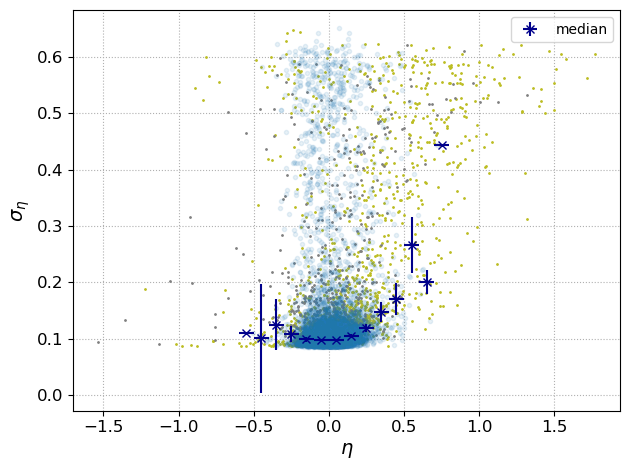

In [60]:
# Any correlation between eta and its uncertainty?
nbins = np.arange(-1.5, 1.5, 0.1)
dn = 0.5*np.diff(nbins)
nc = 0.5*(nbins[1:] + nbins[:-1])

sample1 = ~dwarf_boolean & SGA_TF['GOOD_VEL']
sample2 = dwarf_boolean
sample3 = ~dwarf_boolean & ~SGA_TF['GOOD_VEL']

plt.figure(tight_layout=True)

plt.plot(SGA_TF['LOGDIST'][sample3], 
         SGA_TF['LOGDIST_ERR'][sample3], 
         '.', ms=2, color='tab:olive')

plt.plot(SGA_TF['LOGDIST'][sample2], 
         SGA_TF['LOGDIST_ERR'][sample2], 
         '.', ms=2, color='gray')

plt.plot(SGA_TF['LOGDIST'][sample1], 
         SGA_TF['LOGDIST_ERR'][sample1], 
         '.', alpha=0.1)

# Plot median
N, y_avg, y_std = profile_histogram(SGA_TF['LOGDIST'][sample1], 
                                    SGA_TF['LOGDIST_ERR'][sample1], 
                                    nbins, 
                                    stat='median')
plt.errorbar(nc, y_avg, xerr=dn, yerr=y_std, fmt='x', color='darkblue', label='median')

plt.grid(ls=':')

plt.legend()

plt.tick_params(axis='both', which='major', labelsize=12)

plt.xlabel(r'$\eta$', fontsize=14)
plt.ylabel(r'$\sigma_\eta$', fontsize=14);

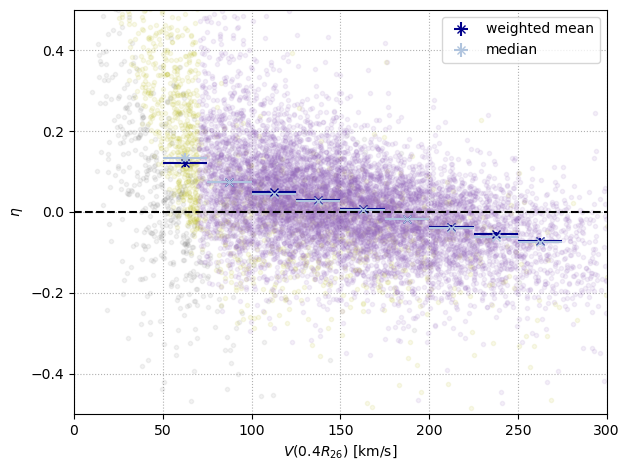

In [61]:
# logv_bins = np.arange(1.75, 2.5, 0.1)
logv_bins = np.arange(0, 300, 25) # These are really linear bins in V
dv = 0.5*np.diff(logv_bins)
vc = 0.5*(logv_bins[1:] + logv_bins[:-1])

plt.figure(tight_layout=True)

plt.grid(ls=':')

sample = ~dwarf_boolean & ~SGA_TF['GOOD_VEL']
# plt.plot(np.log10(SGA_TF['V_0p4R26'][sample]), 
plt.plot(SGA_TF['V_0p4R26'][sample], 
         SGA_TF['LOGDIST'][sample], 
         '.', alpha=0.1, c='tab:olive')

sample = dwarf_boolean
# plt.plot(np.log10(SGA_TF['V_0p4R26'][sample]), 
plt.plot(SGA_TF['V_0p4R26'][sample], 
         SGA_TF['LOGDIST'][sample], 
         '.', alpha=0.1, c='gray')

sample = ~dwarf_boolean & SGA_TF['GOOD_VEL']
# plt.plot(np.log10(SGA_TF['V_0p4R26'][sample]), 
plt.plot(SGA_TF['V_0p4R26'][sample], 
         SGA_TF['LOGDIST'][sample], 
         '.', alpha=0.1, c='tab:purple')

# Plot weighted mean
# _, y_avg, y_std = profile_histogram(np.log10(SGA_TF['V_0p4R26'][sample]), 
_, y_avg, y_std = profile_histogram(SGA_TF['V_0p4R26'][sample], 
                                    SGA_TF['LOGDIST'][sample], 
                                    logv_bins, 
                                    weights=SGA_TF['LOGDIST_ERR'][sample]**-2, 
                                    weighted=True)
plt.errorbar(vc, y_avg, xerr=dv, yerr=y_std, fmt='x', color='darkblue', label='weighted mean')

# Plot median
# _, y_avg, y_std = profile_histogram(np.log10(SGA_TF['V_0p4R26'][sample]), 
_, y_avg, y_std = profile_histogram(SGA_TF['V_0p4R26'][sample], 
                                    SGA_TF['LOGDIST'][sample], 
                                    logv_bins, 
                                    stat='median')
plt.errorbar(vc, y_avg, xerr=dv, yerr=y_std, fmt='x', color='lightsteelblue', label='median')

plt.hlines(0, 0, 1000, colors='k', linestyles='dashed')

plt.legend()

plt.xlim(0, 300)
# plt.ylim(-1, 1)
plt.ylim(-0.5, 0.5)

# plt.xlabel('log($V(0.4R_{26})$)')
plt.xlabel('$V(0.4R_{26})$ [km/s]')
plt.ylabel('$\eta$');

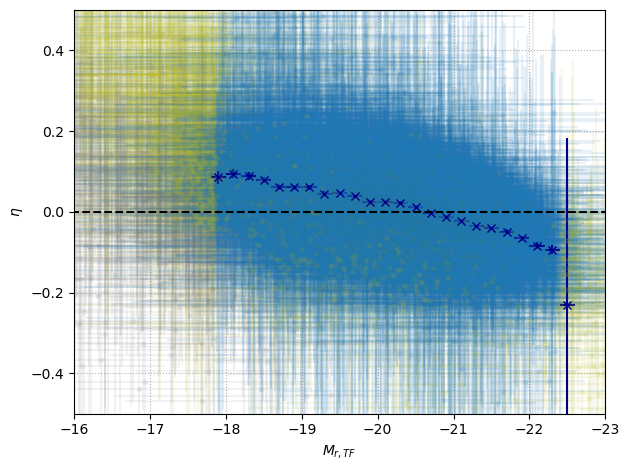

In [62]:
Mr_bins = np.arange(-23, -17, 0.2)
dMr = 0.5*np.diff(Mr_bins)
Mrc = 0.5*(Mr_bins[1:] + Mr_bins[:-1])

plt.figure(tight_layout=True)

plt.grid(ls=':')

sample = ~dwarf_boolean & ~SGA_TF['GOOD_VEL']
plt.errorbar(SGA_TF['R_ABSMAG_SB26_TF'][sample], 
             SGA_TF['LOGDIST'][sample], 
             xerr=SGA_TF['R_ABSMAG_SB26_TF_ERR'][sample], 
             yerr=SGA_TF['LOGDIST_ERR'][sample],
             fmt='.', 
             color='tab:olive',
             alpha=0.1)

sample = dwarf_boolean
plt.errorbar(SGA_TF['R_ABSMAG_SB26_TF'][sample], 
             SGA_TF['LOGDIST'][sample], 
             xerr=SGA_TF['R_ABSMAG_SB26_TF_ERR'][sample], 
             yerr=SGA_TF['LOGDIST_ERR'][sample],
             fmt='.', 
             color='gray',
             alpha=0.1)

sample = ~dwarf_boolean & SGA_TF['GOOD_VEL']
plt.errorbar(SGA_TF['R_ABSMAG_SB26_TF'][sample], 
             SGA_TF['LOGDIST'][sample], 
             xerr=SGA_TF['R_ABSMAG_SB26_TF_ERR'][sample], 
             yerr=SGA_TF['LOGDIST_ERR'][sample],
             fmt='.', 
             alpha=0.1)

# Plot weighted mean
_, y_avg, y_std = profile_histogram(SGA_TF['R_ABSMAG_SB26_TF'][sample], 
                                    SGA_TF['LOGDIST'][sample], 
                                    Mr_bins, 
                                    weights=SGA_TF['LOGDIST_ERR'][sample]**-2, 
                                    weighted=True)
plt.errorbar(Mrc, y_avg, xerr=dMr, yerr=y_std, fmt='x', color='darkblue', label='weighted mean')

plt.hlines(0, -28, 0, linestyles='dashed', colors='k', zorder=10)

plt.xlim(-16, -23)
plt.ylim(-0.5, 0.5)

plt.xlabel('$M_{r,TF}$')
plt.ylabel('$\eta$');

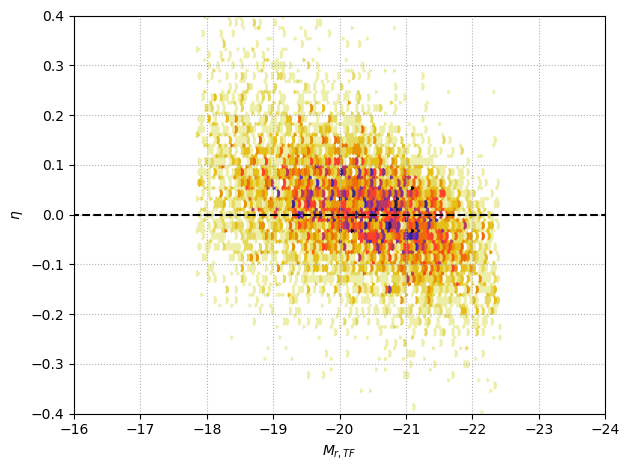

In [63]:
plt.figure(tight_layout=True)

plt.grid(ls=':')

sample = ~dwarf_boolean & SGA_TF['GOOD_VEL']
plt.hexbin(SGA_TF['R_ABSMAG_SB26_TF'][sample], 
           SGA_TF['LOGDIST'][sample], 
           cmap='CMRmap_r')

plt.hlines(0, -28, 0, linestyles='dashed', colors='k')

# plt.xlim(-18, -23)
plt.xlim(-16, -24)
plt.ylim(-0.4, 0.4)

plt.xlabel('$M_{r,TF}$')
plt.ylabel('$\eta$');

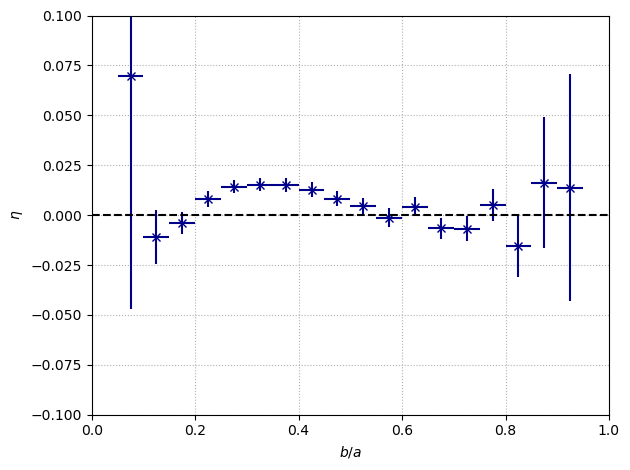

In [64]:
ba_bins = np.arange(0, 1, 0.05)
dba = 0.5*np.diff(ba_bins)
bac = 0.5*(ba_bins[1:] + ba_bins[:-1])

plt.figure(tight_layout=True)

plt.grid(ls=':')

sample = ~dwarf_boolean & SGA_TF['GOOD_VEL']

# Plot weighted mean
_, y_avg, y_std = profile_histogram(SGA_TF['BA'][sample], 
                                    SGA_TF['LOGDIST'][sample], 
                                    ba_bins, 
                                    weights=SGA_TF['LOGDIST_ERR'][sample]**-2, 
                                    weighted=True)
plt.errorbar(bac, y_avg, xerr=dba, yerr=y_std, fmt='x', color='darkblue', label='unweighted mean')

plt.hlines(0, 0, 1, linestyles='dashed', colors='k', zorder=10)

plt.xlim(0, 1)
plt.ylim(-0.1, 0.1)

plt.xlabel('$b/a$')
plt.ylabel('$\eta$');

# plt.savefig('../../../figures/Y1_papers/iron_eta-ba_v13.png', dpi=150, facecolor='none');

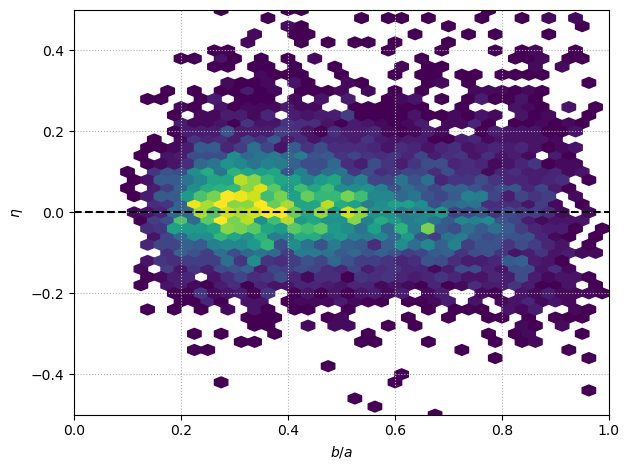

In [65]:
plt.figure(tight_layout=True)

plt.grid(ls=':')

sample = ~dwarf_boolean & SGA_TF['GOOD_VEL']
plt.hexbin(SGA_TF['BA'][sample], 
           SGA_TF['LOGDIST'][sample], 
           cmap='viridis', 
           mincnt=1, 
           vmin=1, 
           vmax=40, 
           gridsize=(40,25), 
           extent=(0,1,-0.5,0.5))

plt.hlines(0, 0, 1, linestyles='dashed', colors='k')

plt.xlim(0, 1)
plt.ylim(-0.5, 0.5)

plt.xlabel('$b/a$')
plt.ylabel('$\eta$');

## Hubble diagram

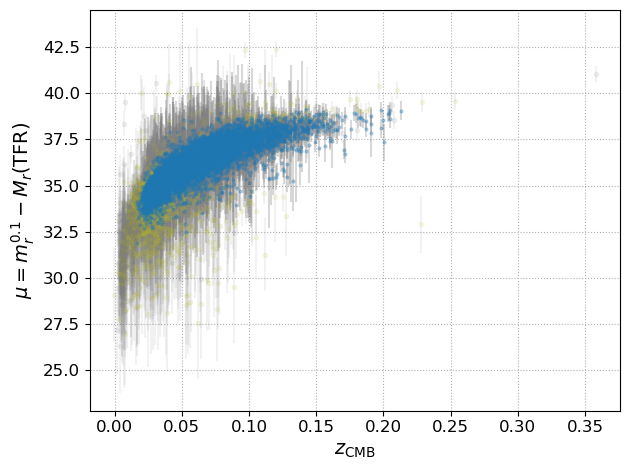

In [66]:
plt.figure(tight_layout=True)

sample = ~dwarf_boolean & ~SGA_TF['GOOD_VEL']
plt.errorbar(SGA_TF['Z_DESI_CMB'][sample],
             SGA_TF['MU_TF'][sample],
             xerr=SGA_TF['ZERR_DESI'][sample],
             yerr=SGA_TF['MU_TF_ERR'][sample],
             fmt='.', 
             color='tab:olive',
             alpha=0.1, 
             ecolor='gray')

sample = dwarf_boolean
plt.errorbar(SGA_TF['Z_DESI_CMB'][sample],
             SGA_TF['MU_TF'][sample],
             xerr=SGA_TF['ZERR_DESI'][sample],
             yerr=SGA_TF['MU_TF_ERR'][sample],
             fmt='.', 
             color='gray',
             alpha=0.1, 
             ecolor='gray')

sample = ~dwarf_boolean & SGA_TF['GOOD_VEL']
plt.errorbar(SGA_TF['Z_DESI_CMB'][sample],
             SGA_TF['MU_TF'][sample],
             xerr=SGA_TF['ZERR_DESI'][sample],
             yerr=SGA_TF['MU_TF_ERR'][sample],
             fmt='.', 
             markersize=4, 
             alpha=0.3, 
             ecolor='gray')

plt.grid(ls=':')

plt.tick_params(axis='both', which='major', labelsize=12)

plt.xlabel(r'$z_{\text{CMB}}$', fontsize=14)
plt.ylabel(r'$\mu = m_r^{0.1} - M_r(\text{TFR})$', fontsize=14);

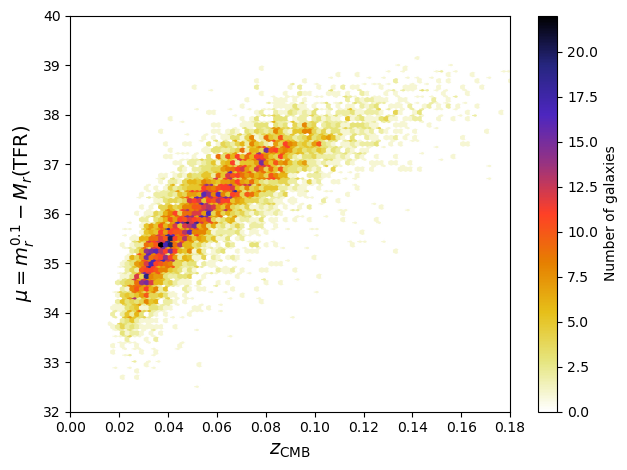

In [67]:
plt.figure(tight_layout=True)

sample = ~dwarf_boolean & SGA_TF['GOOD_VEL'] #& morph_boolean
plt.hexbin(SGA_TF['Z_DESI_CMB'][sample], 
           SGA_TF['MU_TF'][sample], 
           cmap='CMRmap_r')
plt.colorbar(label='Number of galaxies')

plt.xlim([0, 0.18])
plt.ylim([32, 40])

plt.xlabel(r'$z_{\text{CMB}}$', fontsize=14)
plt.ylabel(r'$\mu = m_r^{0.1} - M_r(\text{TFR})$', fontsize=14);

## Save distance moduli to a file

In [68]:
# Create a single column to denote which objects should be used for cosmological analysis
SGA_TF['MAIN'] = ~SGA_TF['DWARF'] & SGA_TF['GOOD_VEL']

In [85]:
SGA_TF[:5]

SGA_ID,SGA_GALAXY,GALAXY,PGC,RA_LEDA,DEC_LEDA,MORPHTYPE,PA_LEDA,D25_LEDA,BA_LEDA,Z_LEDA,SB_D25_LEDA,MAG_LEDA,BYHAND,REF,GROUP_ID,GROUP_NAME,GROUP_MULT,GROUP_PRIMARY,GROUP_RA,GROUP_DEC,GROUP_DIAMETER,BRICKNAME,RA,DEC,D26,D26_REF,PA,BA,RA_MOMENT,DEC_MOMENT,SMA_MOMENT,G_SMA50,R_SMA50,Z_SMA50,SMA_SB22,SMA_SB22.5,SMA_SB23,SMA_SB23.5,SMA_SB24,SMA_SB24.5,SMA_SB25,SMA_SB25.5,SMA_SB26,G_MAG_SB22,R_MAG_SB22,Z_MAG_SB22,G_MAG_SB22.5,R_MAG_SB22.5,Z_MAG_SB22.5,G_MAG_SB23,R_MAG_SB23,Z_MAG_SB23,G_MAG_SB23.5,R_MAG_SB23.5,Z_MAG_SB23.5,G_MAG_SB24,R_MAG_SB24,Z_MAG_SB24,G_MAG_SB24.5,R_MAG_SB24.5,Z_MAG_SB24.5,G_MAG_SB25,R_MAG_SB25,Z_MAG_SB25,G_MAG_SB25.5,R_MAG_SB25.5,Z_MAG_SB25.5,G_MAG_SB26,R_MAG_SB26,Z_MAG_SB26,SMA_SB22_ERR,SMA_SB22.5_ERR,SMA_SB23_ERR,SMA_SB23.5_ERR,SMA_SB24_ERR,SMA_SB24.5_ERR,SMA_SB25_ERR,SMA_SB25.5_ERR,SMA_SB26_ERR,G_MAG_SB22_ERR,R_MAG_SB22_ERR,Z_MAG_SB22_ERR,G_MAG_SB22.5_ERR,R_MAG_SB22.5_ERR,Z_MAG_SB22.5_ERR,G_MAG_SB23_ERR,R_MAG_SB23_ERR,Z_MAG_SB23_ERR,G_MAG_SB23.5_ERR,R_MAG_SB23.5_ERR,Z_MAG_SB23.5_ERR,G_MAG_SB24_ERR,R_MAG_SB24_ERR,Z_MAG_SB24_ERR,G_MAG_SB24.5_ERR,R_MAG_SB24.5_ERR,Z_MAG_SB24.5_ERR,G_MAG_SB25_ERR,R_MAG_SB25_ERR,Z_MAG_SB25_ERR,G_MAG_SB25.5_ERR,R_MAG_SB25.5_ERR,Z_MAG_SB25.5_ERR,G_MAG_SB26_ERR,R_MAG_SB26_ERR,Z_MAG_SB26_ERR,G_COG_PARAMS_MTOT,G_COG_PARAMS_M0,G_COG_PARAMS_ALPHA1,G_COG_PARAMS_ALPHA2,G_COG_PARAMS_CHI2,R_COG_PARAMS_MTOT,R_COG_PARAMS_M0,R_COG_PARAMS_ALPHA1,R_COG_PARAMS_ALPHA2,R_COG_PARAMS_CHI2,Z_COG_PARAMS_MTOT,Z_COG_PARAMS_M0,Z_COG_PARAMS_ALPHA1,Z_COG_PARAMS_ALPHA2,Z_COG_PARAMS_CHI2,ELLIPSEBIT,Z_DESI,ZERR_DESI,V_0p4R26,V_0p4R26_ERR,PHOTSYS,MORPHTYPE_AI,JOHN_VI,Z_DESI_CMB,MU_ZCMB,G_MAG_SB26_CORR,R_MAG_SB26_CORR,Z_MAG_SB26_CORR,G_MAG_SB26_ERR_CORR,R_MAG_SB26_ERR_CORR,Z_MAG_SB26_ERR_CORR,CAL,R_ABSMAG_SB26,MU_ZCMB_ERR,R_ABSMAG_SB26_ERR,DWARF,GOOD_MORPH,GOOD_VEL,R_ABSMAG_SB26_TF,R_ABSMAG_SB26_TF_ERR,R_ABSMAG_SB26_TF_ERR_STAT,R_ABSMAG_SB26_TF_ERR_SYS,MU_TF,MU_TF_ERR,LOGDIST,LOGDIST_ERR,MAIN
,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,mag,,,,,,,,,,,,mag,
float64,bytes16,bytes29,int64,float64,float64,bytes21,float32,float32,float32,float32,float32,float32,bool,bytes13,int64,bytes35,int16,bool,float64,float64,float32,bytes8,float64,float64,float32,bytes4,float32,float32,float64,float64,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,int32,float64,float64,float64,float64,bytes1,str10,str6,float64,float64,float64,float64,float64,float64,float64,float64,bool,float64,float64,float64,bool,bool,bool,float64,float64,float64,float64,float64,float64,float64,float64,bool
38.0,SGA-2020 38,SDSSJ140638.88+393138.1,3558705,211.66194,39.5272341,S?,81.63,0.35318315,0.37757218,0.08108376,24.72948,18.361,False,LEDA-20181114,12,SDSSJ140638.88+393138.1,1,True,211.66194,39.5272341,0.35318315,2115p395,211.66203166014844,39.52724032794356,0.41757938,SB26,82.21093,0.41431504,211.6619547015994,39.52729608884245,8.520181,5.252184,4.0750155,3.3951538,3.3006833,4.4037066,5.5453897,6.693271,7.8023033,8.999919,10.213078,11.41192,12.527382,19.246052,18.406073,17.931826,18.841032,18.092857,17.659027,18.566164,17.886087,17.47688,18.383362,17.749825,17.355968,18.261652,17.655558,17.284552,18.168955,17.588947,17.231817,18.101948,17.547142,17.20673,18.055267,17.516266,17.18719,18.023865,1

In [69]:
hdr = fits.Header()

hdr['DESI_DR'] = 'DR1'
hdr['V_RADIUS'] = '0.4 R26'
hdr['M'] = slope
hdr['M_ERR'] = slope_err
# hdr['0PT'] = ZP
# hdr['0PT_ERR'] = ZP_err
hdr['V0'] = logV0
hdr['SIG'] = np.median(tfr_samples[-1])
hdr['SIG_ERR'] = np.sqrt(cov_ab[-1,-1])
hdr['H0'] = H0

empty_primary = fits.PrimaryHDU(header=hdr)

In [70]:
table_hdu = fits.BinTableHDU(data=SGA_TF)

hdul = fits.HDUList([empty_primary, table_hdu])

# Write results to file
hdul.writeto('SGA_iron_jointTFR_moduli-v19_20260717.fits', 
             overwrite=True)

# Comparison to the cosmology version (v13)

In [71]:
temp_infile = open('cov_ab_iron_jointTFR_varyV0-dwarfsAlex_z0p1_zbins0p005_weightsVmax-1_dVsys_KAD-20250813.pickle', 
                   'rb')
old_cov_ab, old_tfr_samples, old_logV0, old_zmin, old_zmax, old_dz, old_zbins = pickle.load(temp_infile)
temp_infile.close()

old_ZP = np.median(old_tfr_samples[1:-1], axis=1) - mu_zc.value
old_ZP_err = np.sqrt(np.diagonal(old_cov_ab[1:-1,1:-1]))

In [72]:
old = Table.read(ebv_directory + 'Y1/DESI-DR1_TF_pv_cat_v13.fits')

old[:5]

SGA_ID,SGA_GALAXY,GALAXY,PGC,RA_LEDA,DEC_LEDA,MORPHTYPE,PA_LEDA,D25_LEDA,BA_LEDA,Z_LEDA,SB_D25_LEDA,MAG_LEDA,BYHAND,REF,GROUP_ID,GROUP_NAME,GROUP_MULT,GROUP_PRIMARY,GROUP_RA,GROUP_DEC,GROUP_DIAMETER,BRICKNAME,RA,DEC,D26,D26_REF,PA,BA,RA_MOMENT,DEC_MOMENT,SMA_MOMENT,G_SMA50,R_SMA50,Z_SMA50,SMA_SB22,SMA_SB22.5,SMA_SB23,SMA_SB23.5,SMA_SB24,SMA_SB24.5,SMA_SB25,SMA_SB25.5,SMA_SB26,G_MAG_SB22,R_MAG_SB22,Z_MAG_SB22,G_MAG_SB22.5,R_MAG_SB22.5,Z_MAG_SB22.5,G_MAG_SB23,R_MAG_SB23,Z_MAG_SB23,G_MAG_SB23.5,R_MAG_SB23.5,Z_MAG_SB23.5,G_MAG_SB24,R_MAG_SB24,Z_MAG_SB24,G_MAG_SB24.5,R_MAG_SB24.5,Z_MAG_SB24.5,G_MAG_SB25,R_MAG_SB25,Z_MAG_SB25,G_MAG_SB25.5,R_MAG_SB25.5,Z_MAG_SB25.5,G_MAG_SB26,R_MAG_SB26,Z_MAG_SB26,SMA_SB22_ERR,SMA_SB22.5_ERR,SMA_SB23_ERR,SMA_SB23.5_ERR,SMA_SB24_ERR,SMA_SB24.5_ERR,SMA_SB25_ERR,SMA_SB25.5_ERR,SMA_SB26_ERR,G_MAG_SB22_ERR,R_MAG_SB22_ERR,Z_MAG_SB22_ERR,G_MAG_SB22.5_ERR,R_MAG_SB22.5_ERR,Z_MAG_SB22.5_ERR,G_MAG_SB23_ERR,R_MAG_SB23_ERR,Z_MAG_SB23_ERR,G_MAG_SB23.5_ERR,R_MAG_SB23.5_ERR,Z_MAG_SB23.5_ERR,G_MAG_SB24_ERR,R_MAG_SB24_ERR,Z_MAG_SB24_ERR,G_MAG_SB24.5_ERR,R_MAG_SB24.5_ERR,Z_MAG_SB24.5_ERR,G_MAG_SB25_ERR,R_MAG_SB25_ERR,Z_MAG_SB25_ERR,G_MAG_SB25.5_ERR,R_MAG_SB25.5_ERR,Z_MAG_SB25.5_ERR,G_MAG_SB26_ERR,R_MAG_SB26_ERR,Z_MAG_SB26_ERR,G_COG_PARAMS_MTOT,G_COG_PARAMS_M0,G_COG_PARAMS_ALPHA1,G_COG_PARAMS_ALPHA2,G_COG_PARAMS_CHI2,R_COG_PARAMS_MTOT,R_COG_PARAMS_M0,R_COG_PARAMS_ALPHA1,R_COG_PARAMS_ALPHA2,R_COG_PARAMS_CHI2,Z_COG_PARAMS_MTOT,Z_COG_PARAMS_M0,Z_COG_PARAMS_ALPHA1,Z_COG_PARAMS_ALPHA2,Z_COG_PARAMS_CHI2,ELLIPSEBIT,Z_DESI,ZERR_DESI,V_0p4R26,V_0p4R26_ERR,PHOTSYS,MORPHTYPE_AI,JOHN_VI,Z_DESI_CMB,G_MAG_SB26_CORR,R_MAG_SB26_CORR,Z_MAG_SB26_CORR,G_MAG_SB26_ERR_CORR,R_MAG_SB26_ERR_CORR,Z_MAG_SB26_ERR_CORR,MU_ZCMB,R_ABSMAG_SB26,MU_ZCMB_ERR,R_ABSMAG_SB26_ERR,DWARF,GOOD_MORPH,GOOD_VEL,R_ABSMAG_SB26_TF,R_ABSMAG_SB26_TF_ERR,R_ABSMAG_SB26_TF_ERR_STAT,MU_TF,MU_TF_ERR,LOGDIST,LOGDIST_ERR,MAIN,V_PEC,VERR_PEC
float64,bytes16,bytes29,int64,float64,float64,bytes21,float32,float32,float32,float32,float32,float32,bool,bytes13,int64,bytes35,int16,bool,float64,float64,float32,bytes8,float64,float64,float32,bytes4,float32,float32,float64,float64,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,int32,float64,float64,float64,float64,bytes1,bytes10,bytes6,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,bool,bool,bool,float64,float64,float64,float64,float64,float64,float64,bool,float64,float64
38.0,SGA-2020 38,SDSSJ140638.88+393138.1,3558705,211.66194,39.5272341,S?,81.63,0.35318315,0.37757218,0.08108376,24.72948,18.361,False,LEDA-20181114,12,SDSSJ140638.88+393138.1,1,True,211.66194,39.5272341,0.35318315,2115p395,211.66203166014844,39.52724032794356,0.41757938,SB26,82.21093,0.41431504,211.6619547015994,39.52729608884245,8.520181,5.252184,4.0750155,3.3951538,3.3006833,4.4037066,5.5453897,6.693271,7.8023033,8.999919,10.213078,11.41192,12.527382,19.246052,18.406073,17.931826,18.841032,18.092857,17.659027,18.566164,17.886087,17.47688,18.383362,17.749825,17.355968,18.261652,17.655558,17.284552,18.168955,17.588947,17.231817,18.101948,17.547142,17.20673,18.055267,17.516266,17.18719,18.023865,17.497095,17.178627,0.041267984,0.058114093,0.082968995,0.08808186,0.099526815,0.11876543,0.11355961,0.14645264,0.17035669,0.028041152,0.045385383,0.052895926,0.0282255

In [73]:
old_new = join(old['SGA_ID', 'LOGDIST', 'LOGDIST_ERR', 'V_0p4R26', 'V_0p4R26_ERR', 'R_MAG_SB26_CORR', 'R_ABSMAG_SB26', 'R_ABSMAG_SB26_TF'], 
               SGA_TF['SGA_ID', 'LOGDIST', 'LOGDIST_ERR', 'V_0p4R26', 'V_0p4R26_ERR', 'R_MAG_SB26_CORR', 'R_ABSMAG_SB26', 'R_ABSMAG_SB26_TF', 'Z_DESI_CMB'], 
               keys='SGA_ID', 
               table_names=['old', 'new'])

old_new[:5]

SGA_ID,LOGDIST_old,LOGDIST_ERR_old,V_0p4R26_old,V_0p4R26_ERR_old,R_MAG_SB26_CORR_old,R_ABSMAG_SB26_old,R_ABSMAG_SB26_TF_old,LOGDIST_new,LOGDIST_ERR_new,V_0p4R26_new,V_0p4R26_ERR_new,R_MAG_SB26_CORR_new,R_ABSMAG_SB26_new,R_ABSMAG_SB26_TF_new,Z_DESI_CMB
,,,,,,,,,mag,,,,,,
float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
38.0,0.0711702952911594,0.1079084335961595,122.3223893029039,9.671537005812278,16.728901859968826,-20.34231302345913,-19.986461547003334,0.04931682113168137,0.10128396352559339,122.3223893029039,11.74279844934265,17.051947022689937,-20.017436491274218,-19.77085238561581,0.08162327483927467
55.0,0.030331156588198384,0.11251101560076007,81.3789130370326,7.725161740109695,16.87676460899331,-18.849995149542853,-18.69833936660186,-0.0049800054698806665,0.09898616307633414,81.64167905875735,7.4831476205378165,17.296484309208147,-18.427719192155074,-18.45261921950448,0.04508261475414366
117.0,0.04644331091951415,0.10544196481039624,180.6557315191658,12.555107762887319,15.954404164953896,-21.371783346669563,-21.139566792071996,0.04255370070817719,0.0961289666291017,180.6557200934932,14.312866574339168,16.196318002703077,-21.126933177819158,-20.914164674278275,0.09120074612338591
223.0,0.0679350753513475,0.13648647929881474,70.1020042633194,10.55954809258847,16.643691575528077,-18.507775175927126,-18.16809979917039,0.06469858872992518,0.13544140924504647,70.1020042633194,12.23349166770184,16.95602577545148,-18.19347889197202,-17.869985948322395,0.03484683470212291
581.0,0.04406468107029582,0.10955408263893825,133.77852107143553,10.574319515162813,15.209917450108733,-20.465532366168695,-20.245208960817216,0.03391562328556859,0.09848696134583562,133.77852107143553,11.003706543649898,15.643965046322041,-20.029637210328016,-19.860059093900173,0.044062107713850995


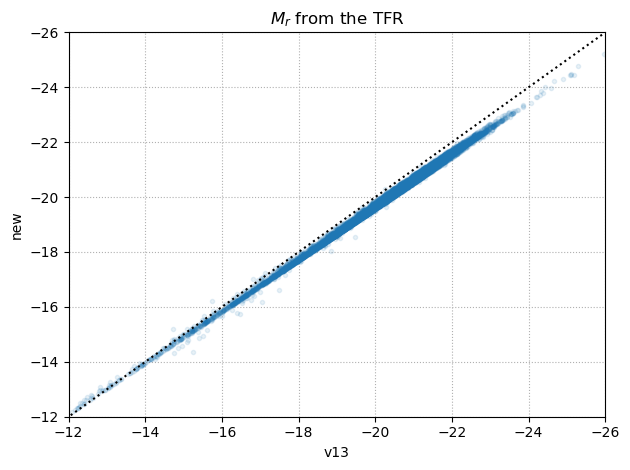

In [74]:
plt.figure(tight_layout=True)

plt.grid(ls=':')

plt.plot(old_new['R_ABSMAG_SB26_TF_old'], old_new['R_ABSMAG_SB26_TF_new'], '.', alpha=0.1)

plt.plot([-11, -27], [-11, -27], 'k:')

plt.xlim(-12, -26)
plt.ylim(-12, -26)

plt.title('$M_r$ from the TFR')
plt.xlabel('v13')
plt.ylabel('new');

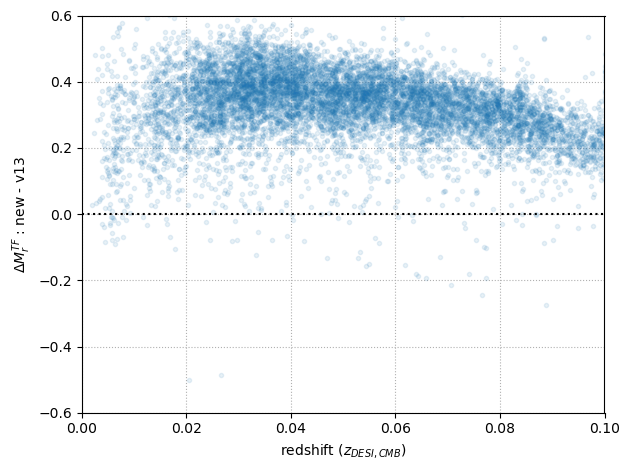

In [75]:
plt.figure(tight_layout=True)

plt.grid(ls=':')

plt.plot(old_new['Z_DESI_CMB'], old_new['R_ABSMAG_SB26_TF_new'] - old_new['R_ABSMAG_SB26_TF_old'], '.', alpha=0.1)

# plt.errorbar(zc, ZP - old_ZP, fmt='x', c='tab:orange', xerr=0.5*dz)

plt.hlines(0, 0, 0.2, colors='k', linestyles='dotted')

plt.xlim(0, 0.1)
plt.ylim(-0.6, 0.6)

plt.xlabel('redshift ($z_{DESI, CMB}$)')
plt.ylabel('$\Delta M_r^{TF}$ : new - v13');

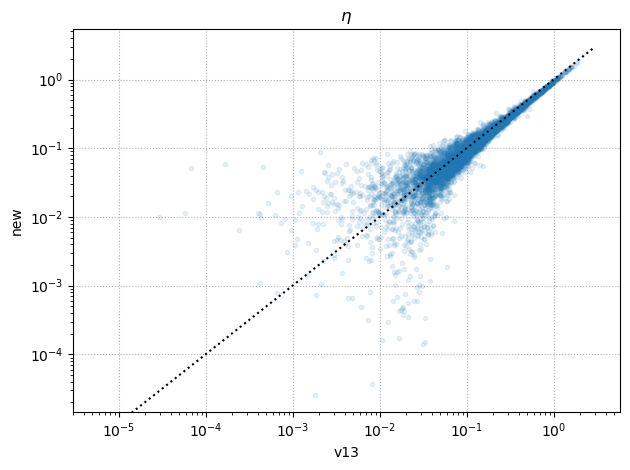

In [76]:
plt.figure(tight_layout=True)

plt.grid(ls=':')

plt.loglog(old_new['LOGDIST_old'], old_new['LOGDIST_new'], '.', alpha=0.1)

plt.loglog([-0.5, 3], [-0.5, 3], 'k:')

plt.title('$\eta$')
plt.xlabel('v13')
plt.ylabel('new');

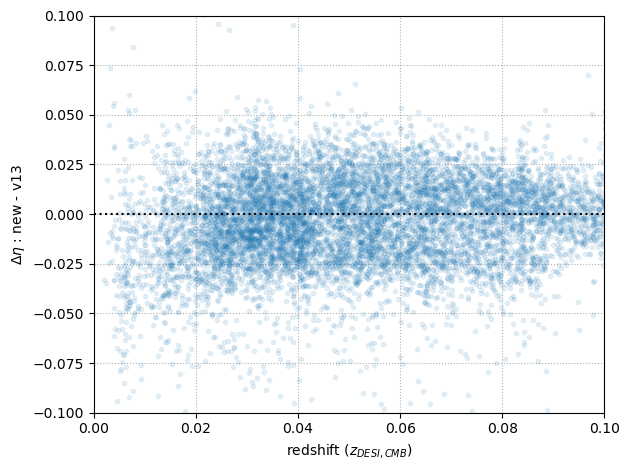

In [77]:
plt.figure(tight_layout=True)

plt.grid(ls=':')

plt.plot(old_new['Z_DESI_CMB'], old_new['LOGDIST_new'] - old_new['LOGDIST_old'], '.', alpha=0.1)

# plt.errorbar(zc, 0.2*(ZP - old_ZP), fmt='x', c='tab:orange', xerr=0.5*dz)

plt.hlines(0, 0, 0.2, colors='k', linestyles='dotted')

plt.xlim(0, 0.1)
plt.ylim(-0.1, 0.1)

plt.xlabel('redshift ($z_{DESI, CMB}$)')
plt.ylabel('$\Delta \eta$ : new - v13');

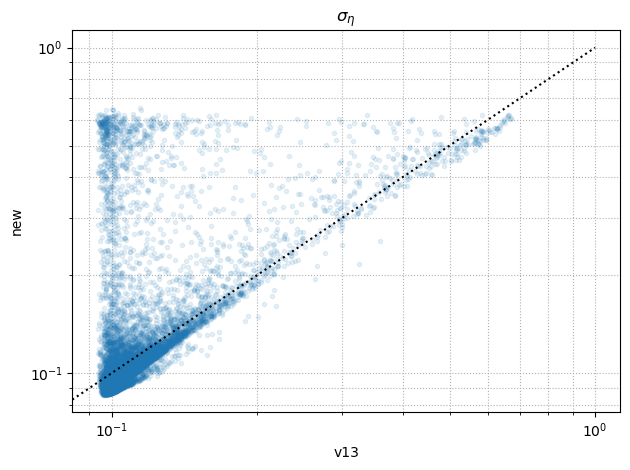

In [78]:
plt.figure(tight_layout=True)

plt.grid(ls=':', which='both')

plt.loglog(old_new['LOGDIST_ERR_old'], old_new['LOGDIST_ERR_new'], '.', alpha=0.1)

plt.loglog([-0.5, 1], [-0.5, 1], 'k:')

plt.title('$\sigma_\eta$')
plt.xlabel('v13')
plt.ylabel('new');

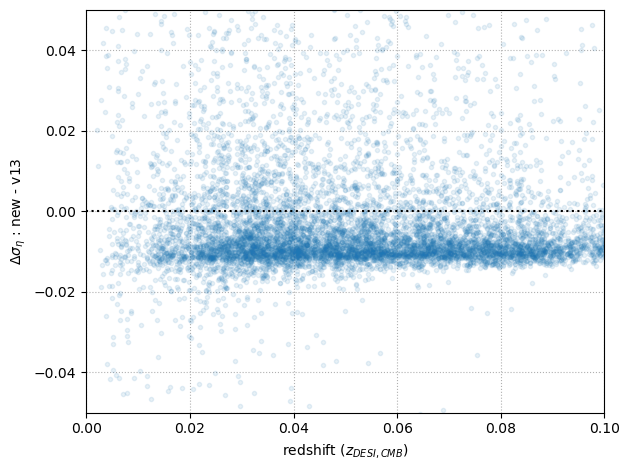

In [79]:
plt.figure(tight_layout=True)

plt.grid(ls=':')

plt.plot(old_new['Z_DESI_CMB'], old_new['LOGDIST_ERR_new'] - old_new['LOGDIST_ERR_old'], '.', alpha=0.1)

plt.hlines(0, 0, 0.2, colors='k', linestyles='dotted')

plt.xlim(0, 0.1)
plt.ylim(-0.05, 0.05)

plt.xlabel('redshift ($z_{DESI, CMB}$)')
plt.ylabel('$\Delta \sigma_\eta$ : new - v13');

/var/folders/mg/fxh1s24d0n3_r0c39d3gs0g00000gq/T/ipykernel_51402/710525538.py:36: RuntimeWarning: invalid value encountered in log10
  deltamarray = np.log10(dzarray/dharray)


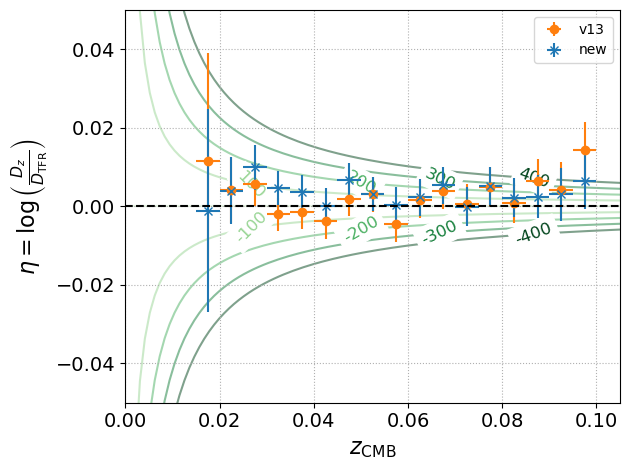

In [84]:
plt.figure(tight_layout=True)

_zbins = np.arange(0, 0.105, 0.005)
_dz = 0.5*np.diff(_zbins)
_zc = 0.5*(_zbins[1:] + _zbins[:-1])

# Plot the original catalog
N, y_avg, y_std = profile_histogram(old['Z_DESI_CMB'][old['MAIN']], 
                                    old['LOGDIST'][old['MAIN']], 
                                    _zbins, 
                                    weights=old['LOGDIST_ERR'][old['MAIN']]**-2, 
                                    weighted=True)
plt.errorbar(_zc, y_avg, xerr=_dz, yerr=y_std, fmt='o', 
             color='tab:orange', 
             label='v13')

# Plot the new catalog
N, y_avg, y_std = profile_histogram(SGA_TF['Z_DESI_CMB'][SGA_TF['MAIN']], 
                                    SGA_TF['LOGDIST'][SGA_TF['MAIN']], 
                                    _zbins, 
                                    weights=SGA_TF['LOGDIST_ERR'][SGA_TF['MAIN']]**-2, 
                                    weighted=True)
plt.errorbar(_zc, y_avg, xerr=_dz, yerr=y_std, fmt='x', 
             color='tab:blue', 
             label='new')

#-------------------------------------------------------------------------------
# PV lines (code taken from Cullen)
#-------------------------------------------------------------------------------
velarray = np.arange(-400, 401, 100)
zarray = np.linspace(0.001, 0.21, 200)

dzarray = cosmo.comoving_distance(zarray).value
dharray = cosmo.comoving_distance(np.outer(1.0/(1.0 + velarray/c.value), 
								  (1.0 + zarray)) - 1.0).value
deltamarray = np.log10(dzarray/dharray)

rotation = [20.0, 25.0, 30.0, 45.0, 0.0, -45.0, -30.0, -25.0, -20.0]
labels = ["-400", "-300", "-200", "-100", "0", "100", "200", "300", "400"]
xcoord = np.array([26000.0, 20000.0, 15000.0, 8000.0, -1000.0, 8000.0, 15000.0, 20000.0, 26000.0])
coord = np.searchsorted(zarray, xcoord/c.value)
ycoord = np.array([deltamarray[i,j] for i, j in enumerate(coord)])

colors = 0.8*np.fabs(velarray)/np.amax(np.fabs(velarray)) + 0.2

for v in range(len(velarray)):
    col = plt.cm.Greens(colors[v])

    plt.plot(zarray, deltamarray[v,:], 
             color=col, 
             linestyle='-', 
             alpha=0.5, 
             zorder=0)

    if (v != 4):
        plt.text(xcoord[v]/c.value, ycoord[v], 
                 labels[v], 
                 color=col, 
                 fontsize=12, 
                 rotation=rotation[v], 
                 ha="center", 
                 va="center", 
                 bbox=dict(boxstyle="square", ec="w", fc="w"), 
                 zorder=1)

# Line at eta = 0
plt.hlines(0, 0, 0.2, linestyles='dashed', colors='k', zorder=5)
#-------------------------------------------------------------------------------

plt.grid(ls=':')

# plt.vlines([0.03, 0.1], -0.05, 0.05, colors='gray', linestyles='dashed')

plt.tick_params(axis='both', which='major', labelsize=14)

plt.xlabel(r'$z_{\text{CMB}}$', fontsize=16)
plt.ylabel(r'$\eta = \log \left( \frac{D_z}{D_{\text{TFR}}} \right)$', 
           fontsize=16)

plt.ylim((-0.05, 0.05))
# plt.ylim((-0.13, 0.13))
plt.xlim((0, 0.105))
# plt.xlim((0, 0.2))

plt.legend();

In [81]:
# high_z = (old_new['Z_DESI_CMB'] > 0.1) & (old_new['Z_DESI_CMB'] < 0.105)
# old_new[high_z]

low_z = old_new['Z_DESI_CMB'] < 0.03
old_new[low_z]

SGA_ID,LOGDIST_old,LOGDIST_ERR_old,V_0p4R26_old,V_0p4R26_ERR_old,R_MAG_SB26_CORR_old,R_ABSMAG_SB26_old,R_ABSMAG_SB26_TF_old,LOGDIST_new,LOGDIST_ERR_new,V_0p4R26_new,V_0p4R26_ERR_new,R_MAG_SB26_CORR_new,R_ABSMAG_SB26_new,R_ABSMAG_SB26_TF_new,Z_DESI_CMB
,,,,,,,,,mag,,,,,,
float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
1287.0,-0.09569296509654919,0.1274744042156576,108.65336314684652,14.481723812497142,15.544377922306458,-19.0622313830222,-19.540696208504947,-0.09965505985052375,0.14697318238213058,108.65336314684653,21.387032463599304,15.947458335702592,-18.656976434433922,-19.155251733686537,0.02726484807614704
1787.0,-0.20306962010122762,0.5007732931303063,38.7410164610221,24.75148086053165,16.30464749416675,-15.295150664824462,-16.310498765330603,-0.24918740015336313,0.4926884570633993,38.74101941942769,27.389786281487044,16.714124894251913,-14.884636890238621,-16.130573891005433,0.006931741714874207
2733.0,0.0629333169654288,0.10907054871496634,119.89025011454842,9.763430036487554,13.986683169606257,-20.163622354227464,-19.848955769400323,0.05589229330597476,0.09909360369376817,119.89025011454842,10.551348868534593,14.425356154169938,-19.72335993128449,-19.443898464754618,0.022180656180810665
5732.0,0.0491558562410674,0.11245606465095502,93.44032824430406,8.453356233517216,15.24633311957953,-19.314004917052912,-19.06822563584758,0.026656114692107737,0.10486609146829706,93.44107210209725,9.70200448617173,15.712117023949755,-18.84614574025986,-18.712865166799318,0.02670110481471122
6140.0,-0.017891563168174685,0.10376233967144582,106.64509356363058,5.997532093540247,15.250562745653134,-19.39280205410359,-19.482259869944464,-0.020316844268751313,0.08950558183436869,104.87158704790028,4.601128841981874,15.691913706856077,-18.949763577450902,-19.051347798794662,0.02772096612199304
7298.0,-0.08009269816586057,0.14523479952932336,61.16774986257402,10.232384677558258,16.363744676775944,-17.340609757187906,-17.741073248017205,-0.09902593542197735,0.14450424164413522,61.16774986257402,11.668332880736923,16.727578600318825,-16.97499902846675,-17.47012870557664,0.018117461458578177
7695.0,-0.0767310260824658,0.10550799435171561,140.59180312447654,10.240669991067035,14.737636532711827,-19.964221072472014,-20.34787620288434,-0.06299285307321156,0.0986282968257398,140.591793906746,12.528452412603436,15.106854214603493,-19.596110926989205,-19.911075192355266,0.028462308959241067
7805.0,0.08962965701214785,0.1293826759200761,79.50786434077595,10.502545594886286,15.658392645417281,-19.010615250971455,-18.562466965910716,0.10119907643276918,0.11712237409180931,79.50786434077595,10.550883986801097,15.922403097283354,-18.745257122580195,-18.239261740416353,0.02804360836316544


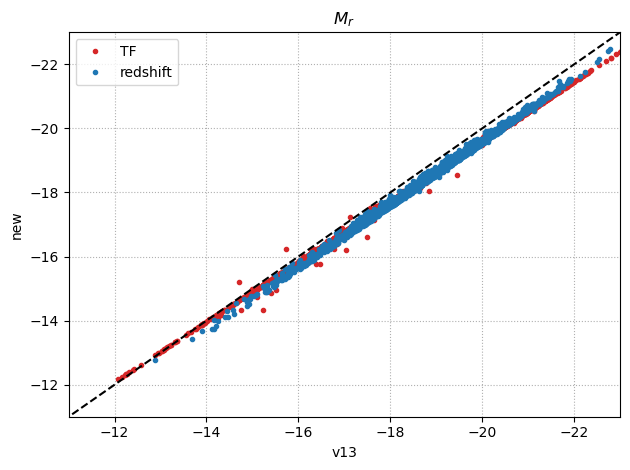

In [82]:
plt.figure(tight_layout=True)

plt.grid(ls=':')

plt.plot(old_new['R_ABSMAG_SB26_TF_old'][low_z], old_new['R_ABSMAG_SB26_TF_new'][low_z], '.', c='tab:red', label='TF')
plt.plot(old_new['R_ABSMAG_SB26_old'][low_z], old_new['R_ABSMAG_SB26_new'][low_z], '.', c='tab:blue', label='redshift')

plt.plot([-27, -10], [-27, -10], 'k--')

plt.legend()

plt.xlim((-11, -23))
plt.ylim((-11, -23))

plt.title('$M_r$')
plt.xlabel('v13')
plt.ylabel('new');

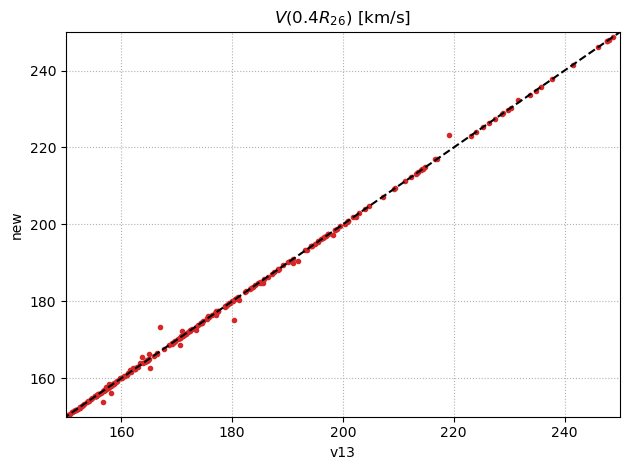

In [83]:
plt.figure(tight_layout=True)

plt.grid(ls=':')

plt.plot(old_new['V_0p4R26_old'][low_z], old_new['V_0p4R26_new'][low_z], '.', c='tab:red')

plt.plot([0, 500], [0, 500], 'k--')

plt.xlim((150, 250))
plt.ylim((150, 250))

plt.title('$V(0.4R_{26})$ [km/s]')
plt.xlabel('v13')
plt.ylabel('new');